## Condition Configuration

In [53]:
CONDITION = 'minimal'
N_BOOT = 1000
BOOT_SEED = 42
N_SUBSAMPLE = 23
REUSE_CACHED_EMBEDDINGS = True


# Compare Human vs All-AI Research Proposals (Pooled) — Style-Controlled (Rephrased)

# Setup and Imports

In [54]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, fisher_exact
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_distances
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests
import pickle
import json
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Find project root ──────────────────────────────────────────────────────
def find_project_root(start=None):
    p = Path(start or os.getcwd()).resolve()
    for _ in range(10):
        if (p / 'src').is_dir() and (p / 'data').is_dir():
            return p
        p = p.parent
    raise FileNotFoundError('Could not find project root with src/ and data/')

try:
    _nb_path = Path(__file__).resolve().parent
except NameError:
    _nb_path = Path.cwd()
PROJECT_ROOT = find_project_root(_nb_path)
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

condition = 'rephrased/minimal'
TABLES_DIR    = PROJECT_ROOT / 'results' / 'tables' / condition
FIGURES_DIR   = PROJECT_ROOT / 'results' / 'figures' / condition
TABLES_DIR_AI  = TABLES_DIR / 'all_ai'
FIGURES_DIR_AI = FIGURES_DIR / 'all_ai'
CACHE_DIR     = TABLES_DIR / 'cached'

TABLES_DIR_AI.mkdir(parents=True, exist_ok=True)
FIGURES_DIR_AI.mkdir(parents=True, exist_ok=True)
print(f'TABLES_DIR_AI:  {TABLES_DIR_AI}')
print(f'FIGURES_DIR_AI: {FIGURES_DIR_AI}')

MODEL_NAME_MAP = {
    'GPT-5.2': 'GPT-5.2', 'Gemini': 'Gemini', 'Claude': 'Claude',
    'gpt': 'GPT-5.2', 'gemini': 'Gemini', 'claude': 'Claude',
    'GPT': 'GPT-5.2'
}

# ── Color scheme ───────────────────────────────────────────────────────────
colors = {'Human': '#DC143C', 'All AI': '#B56576'}
HUMAN_FUNDED_COLOR    = '#8B0000'
HUMAN_NONFUNDED_COLOR = '#F08080'
AI_COLOR    = '#B56576'
HUMAN_COLOR = '#DC143C'

# ── Helper functions ───────────────────────────────────────────────────────
def bootstrap_mean_ci(values, n_boot=2000, random_state=42, alpha=0.05):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0: return np.nan, np.nan, np.nan
    mean = float(np.mean(arr))
    if len(arr) == 1: return mean, mean, mean
    rng = np.random.default_rng(random_state)
    boot_means = np.array([np.mean(rng.choice(arr, size=len(arr), replace=True))
                            for _ in range(n_boot)])
    lo, hi = np.quantile(boot_means, [alpha/2, 1-alpha/2])
    return mean, float(lo), float(hi)

def boot_ci(values, alpha=0.05):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0: return np.nan, np.nan
    return float(np.quantile(arr, alpha/2)), float(np.quantile(arr, 1-alpha/2))

def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yj else (-1 if xi < yj else 0)
              for xi in x for yj in y)
    return dom / (len(x) * len(y))

def bootstrap_cliffs_delta_ci(x, y, n_boot=2000, random_state=42, alpha=0.05):
    rng = np.random.default_rng(random_state)
    x, y = np.asarray(x), np.asarray(y)
    boots = [cliffs_delta(rng.choice(x, len(x), replace=True),
                          rng.choice(y, len(y), replace=True))
             for _ in range(n_boot)]
    return float(np.quantile(boots, alpha/2)), float(np.quantile(boots, 1-alpha/2))

def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    rng = np.random.default_rng(random_state)
    g1, g2 = np.asarray(group1), np.asarray(group2)
    obs = np.mean(g1) - np.mean(g2)
    combined = np.concatenate([g1, g2])
    n1 = len(g1)
    perm_diffs = []
    for _ in range(n_permutations):
        p = rng.permutation(combined)
        perm_diffs.append(np.mean(p[:n1]) - np.mean(p[n1:]))
    perm_diffs = np.array(perm_diffs)
    pval = (np.sum(np.abs(perm_diffs) >= abs(obs)) + 1) / (n_permutations + 1)
    return float(pval), float(obs), perm_diffs

def fmt_p(p):
    if np.isnan(p): return 'n/a'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return f'p={p:.3f}'

def group_mst_dispersion(idx, D):
    Dg = D[np.ix_(idx, idx)]
    if len(idx) <= 1: return 0.0
    mst = minimum_spanning_tree(Dg)
    return float(mst.sum() / max(1, len(idx)-1))

def group_chamfer(idx, D):
    Dg = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(Dg, np.inf)
    return float(np.min(Dg, axis=1).mean())

def group_sparseness(idx, D):
    Dg = D[np.ix_(idx, idx)]
    med_i = int(np.argmin(Dg.sum(axis=0)))
    return float(Dg[:, med_i].mean())

def group_mean_pairwise(idx, D):
    Dg = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(Dg, np.nan)
    return float(np.nanmean(Dg))

def group_loo_centroid(idx, X):
    Xg = X[idx]
    n = len(idx)
    if n <= 1: return np.zeros(n)
    s = Xg.sum(axis=0)
    result = []
    for i in range(n):
        centroid_loo = (s - Xg[i]) / (n - 1)
        d = cosine_distances(Xg[i:i+1], centroid_loo.reshape(1, -1))[0, 0]
        result.append(d)
    return np.array(result)

def group_global_centroid(idx, X):
    c = X.mean(axis=0, keepdims=True)
    return cosine_distances(X[idx], c).ravel()

def group_grid_entropy(idx, coords, bins=5):
    pts = coords[idx]
    H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=bins)
    p = H.ravel().astype(float)
    p = p[p > 0]
    p = p / p.sum()
    ent = -np.sum(p * np.log(p))
    return float(ent / np.log(bins * bins)) if np.log(bins * bins) > 0 else 0.0

def per_proposal_pairwise(idx, D):
    Dg = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(Dg, np.nan)
    return np.nanmean(Dg, axis=1)

def per_proposal_nn(idx, D):
    Dg = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(Dg, np.inf)
    return np.min(Dg, axis=1)

def per_proposal_medoid_dist(idx, D):
    Dg = D[np.ix_(idx, idx)]
    med_i = int(np.argmin(Dg.sum(axis=0)))
    return Dg[:, med_i]

def per_proposal_loo_centroid(idx, X):
    return group_loo_centroid(idx, X)

def boot_metric_over_samples(metric_fn, boot_samples, *args):
    return np.array([metric_fn(s, *args) for s in boot_samples])

def add_mean_ci_to_boxplot(ax, data_arrays, positions=None, colors_for_points=None,
                            n_boot=2000, random_state=42, marker_size=50,
                            line_color='black', zorder=12):
    if positions is None:
        positions = np.arange(len(data_arrays))
    if colors_for_points is None:
        colors_for_points = ['#808080'] * len(data_arrays)
    for pos, values, pc in zip(positions, data_arrays, colors_for_points):
        mean, lo, hi = bootstrap_mean_ci(values, n_boot=n_boot, random_state=random_state)
        if not np.isfinite(mean):
            continue
        yerr = np.array([[max(0., mean - lo)], [max(0., hi - mean)]])
        rgba = mcolors.to_rgba(pc, 0.95)
        ax.errorbar(pos, mean, yerr=yerr, fmt='D',
                    markersize=np.sqrt(marker_size),
                    markerfacecolor=rgba, markeredgecolor=line_color,
                    markeredgewidth=1.2, ecolor=line_color,
                    elinewidth=1.4, capsize=4, capthick=1.2, zorder=zorder)

def draw_boxplot_with_jitter(ax, data_list, labels, group_colors, positions=None,
                              jitter=0.15, point_size=20, point_alpha=0.5,
                              box_alpha=0.7):
    if positions is None:
        positions = list(range(len(data_list)))
    rng_j = np.random.default_rng(0)
    bp = ax.boxplot(data_list, positions=positions, widths=0.4,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], group_colors):
        patch.set_facecolor(mcolors.to_rgba(col, box_alpha))
    for data, pos, col in zip(data_list, positions, group_colors):
        xs = rng_j.uniform(pos - jitter, pos + jitter, size=len(data))
        ax.scatter(xs, data, s=point_size, color=col, alpha=point_alpha, zorder=5)
    add_mean_ci_to_boxplot(ax, data_list, positions=positions,
                            colors_for_points=group_colors)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.yaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

def draw_effect_size_panel(ax, delta, d_lo, d_hi, label='All AI', p_val=None):
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
    ax.errorbar(delta, 0, xerr=[[delta - d_lo], [d_hi - delta]],
                fmt='o', color=AI_COLOR, markersize=8,
                ecolor='black', elinewidth=1.5, capsize=5, capthick=1.5)
    ax.set_yticks([0])
    ax.set_yticklabels([label])
    ax.set_xlabel("Cliff's δ (bootstrap 95% CI)\npositive = AI > Human")
    ax.yaxis.grid(True, alpha=0.25)
    if p_val is not None:
        ax.set_title(fmt_p(p_val), fontsize=10)

print('Imports and helpers loaded.')


PROJECT_ROOT: /Users/eveyhuang/Documents/NICO/human-AI-proposal
TABLES_DIR_AI:  /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/all_ai
FIGURES_DIR_AI: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/all_ai
Imports and helpers loaded.


## Load Shared Precomputed Caches

In [55]:
# ── Load .npy caches ────────────────────────────────────────────────────────
def _load_npy(path):
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f'Required cache missing: {p}')
    return np.load(str(p))

D_pp    = _load_npy(CACHE_DIR / 'proposal_distance_matrix.npy')   # (92,92)
X_pca2d = _load_npy(CACHE_DIR / 'proposal_pca2d.npy')             # (92,2)
X_umap2d= _load_npy(CACHE_DIR / 'proposal_umap2d.npy')            # (92,2)
print(f'D_pp: {D_pp.shape}, X_pca2d: {X_pca2d.shape}, X_umap2d: {X_umap2d.shape}')

# Literature SELF-kNN distances (39538×50) — used for novelty_z local density.
# NOTE: this is lit-to-lit kNN, NOT proposal-to-literature distances.
_lit_knn_path = CACHE_DIR / 'lit_knn_distances_50.npy'
lit_knn_distances_50 = np.load(str(_lit_knn_path)) if _lit_knn_path.exists() else None
if lit_knn_distances_50 is not None:
    print(f'lit_knn_distances_50 (lit-lit self-kNN): {lit_knn_distances_50.shape}')
    lit_mean_knn_10 = lit_knn_distances_50[:, :10].mean(axis=1)
else:
    print('WARNING: lit_knn_distances_50.npy not found — novelty_z normalization unavailable')
    lit_mean_knn_10 = None

# ── Proposal embeddings (full-proposal, in proposal_meta row order) ──────────
# pkl stores {'human_embeddings': ..., 'ai_embeddings': ..., ...}
# proposal_meta rows are ordered: humans first (matching vstack order in original notebook)
_emb_path = PROJECT_ROOT / 'data' / 'embeddings' / condition / 'proposal_embeddings_human_ai_rephrased.pkl'
with open(_emb_path, 'rb') as f:
    _emb_data = pickle.load(f)
if isinstance(_emb_data, dict) and 'human_embeddings' in _emb_data:
    _h_emb = np.asarray(_emb_data['human_embeddings'], dtype=np.float32)
    _a_emb = np.asarray(_emb_data['ai_embeddings'],    dtype=np.float32)
    X_prop = np.vstack([_h_emb, _a_emb])
else:
    X_prop = np.asarray(_emb_data, dtype=np.float32)
_norms = np.linalg.norm(X_prop, axis=1, keepdims=True); _norms[_norms == 0] = 1
X_prop = (X_prop / _norms).astype(np.float32)
print(f'X_prop: {X_prop.shape}')

# ── Literature embeddings + proposal-to-literature distances ─────────────────
# D_pl_sorted_idx  (92 × n_lit) and D_pl_sorted_dist (92 × 50) are computed here.
# They are NOT stored in the shared cache; they must be computed from embeddings.
_lit_emb_path = PROJECT_ROOT / 'data' / 'embeddings' / 'literature' / 'relevant_literature_embeddings.pkl'
_abs_emb_path = PROJECT_ROOT / 'data' / 'embeddings' / condition / 'proposal_embeddings_section1_only.pkl'

D_pl_sorted_idx  = None
D_pl_sorted_dist = None
X_lit = None

if _lit_emb_path.exists():
    print('Loading literature embeddings...')
    with open(_lit_emb_path, 'rb') as f:
        _lit_raw = pickle.load(f)
    if isinstance(_lit_raw, dict) and 'embeddings' in _lit_raw:
        X_lit = np.asarray(_lit_raw['embeddings'], dtype=np.float32)
    elif isinstance(_lit_raw, dict):
        X_lit = np.vstack(list(_lit_raw.values())).astype(np.float32)
    else:
        X_lit = np.asarray(_lit_raw, dtype=np.float32)
    _ln = np.linalg.norm(X_lit, axis=1, keepdims=True); _ln[_ln == 0] = 1
    X_lit = (X_lit / _ln).astype(np.float32)
    print(f'X_lit: {X_lit.shape}')

    # Use abstract-only proposal embeddings for novelty (matches original notebook)
    X_prop_nov = X_prop
    if _abs_emb_path.exists():
        with open(_abs_emb_path, 'rb') as f:
            _abs_raw = pickle.load(f)
        if isinstance(_abs_raw, dict) and 'human_embeddings' in _abs_raw:
            _ha = np.asarray(_abs_raw['human_embeddings'], dtype=np.float32)
            _aa = np.asarray(_abs_raw['ai_embeddings'],    dtype=np.float32)
            _X_abs = np.vstack([_ha, _aa])
        elif isinstance(_abs_raw, dict) and 'embeddings' in _abs_raw:
            _X_abs = np.asarray(_abs_raw['embeddings'], dtype=np.float32)
        else:
            _X_abs = np.asarray(_abs_raw, dtype=np.float32)
        if _X_abs.shape[0] == X_prop.shape[0]:
            _an = np.linalg.norm(_X_abs, axis=1, keepdims=True); _an[_an == 0] = 1
            X_prop_nov = (_X_abs / _an).astype(np.float32)
            print(f'X_prop_nov (abstract-only): {X_prop_nov.shape}')
        else:
            print(f'WARNING: abstract emb shape mismatch, falling back to full-proposal emb')

    print('Computing proposal-to-literature distances (92 × 39538)...')
    S_pl = X_prop_nov @ X_lit.T                                        # (92, n_lit)
    D_pl = (1.0 - S_pl).astype(np.float32)
    D_pl_sorted_idx  = np.argsort(D_pl, axis=1)                        # (92, n_lit)
    D_pl_sorted_dist = np.take_along_axis(D_pl, D_pl_sorted_idx, axis=1)[:, :50]  # (92, 50)
    print(f'D_pl_sorted_idx: {D_pl_sorted_idx.shape}, D_pl_sorted_dist: {D_pl_sorted_dist.shape}')
    del S_pl, D_pl
else:
    print('WARNING: literature embeddings not found — novelty/MeSH/BERTopic recomputation skipped')

# ── Proposal metadata ─────────────────────────────────────────────────────────
# Prefer cached version which has full columns (group_binary, proposal_uid, ranking, funding, etc.)
_meta_path = CACHE_DIR / 'proposal_meta.csv'
if not _meta_path.exists():
    _meta_path = TABLES_DIR / 'proposal_metadata.csv'
proposal_meta = pd.read_csv(_meta_path)
# Derive missing columns if loaded from the minimal CSV (only has 'group')
if 'group' in proposal_meta.columns and 'group_binary' not in proposal_meta.columns:
    proposal_meta['group_binary'] = proposal_meta['group'].apply(
        lambda x: 'Human' if x == 'Human' else 'AI')
if 'group' in proposal_meta.columns and 'group_model' not in proposal_meta.columns:
    proposal_meta['group_model'] = proposal_meta['group'].map(
        lambda x: MODEL_NAME_MAP.get(x, x))
if 'proposal_uid' not in proposal_meta.columns:
    proposal_meta['proposal_uid'] = [f'P_{i:03d}' for i in range(len(proposal_meta))]
if 'group_model' in proposal_meta.columns:
    proposal_meta['group_model'] = proposal_meta['group_model'].map(lambda x: MODEL_NAME_MAP.get(x, x))
if 'is_top5_ranked' not in proposal_meta.columns:
    if 'ranking' in proposal_meta.columns:
        proposal_meta['is_top5_ranked'] = proposal_meta['ranking'].apply(
            lambda x: pd.notna(x) and float(x) <= 5 if pd.notna(x) else False)
    else:
        proposal_meta['is_top5_ranked'] = False
if 'funding' in proposal_meta.columns:
    proposal_meta['human_color_shade'] = np.where(
        proposal_meta['funding'].fillna(0).astype(float).eq(1.0), '#8B0000', '#F08080')
else:
    proposal_meta['human_color_shade'] = '#F08080'
print(f'proposal_meta: {proposal_meta.shape}')
print(proposal_meta['group_binary'].value_counts() if 'group_binary' in proposal_meta.columns else 'no group_binary col')

# ── Index arrays ──────────────────────────────────────────────────────────────
human_idx  = proposal_meta.index[proposal_meta['group_binary'] == 'Human'].to_numpy()
ai_idx     = proposal_meta.index[proposal_meta['group_binary'] == 'AI'].to_numpy()
claude_idx = proposal_meta.index[proposal_meta['group_model'] == 'Claude'].to_numpy()
gemini_idx = proposal_meta.index[proposal_meta['group_model'] == 'Gemini'].to_numpy()
gpt_idx    = proposal_meta.index[proposal_meta['group_model'] == 'GPT-5.2'].to_numpy()
print(f'human_idx: {len(human_idx)}, ai_idx: {len(ai_idx)}')
print(f'claude: {len(claude_idx)}, gemini: {len(gemini_idx)}, gpt: {len(gpt_idx)}')

D_pp_infdiag = D_pp.copy()
np.fill_diagonal(D_pp_infdiag, np.inf)

# ── Literature ancillary data ─────────────────────────────────────────────────
_lb_path = PROJECT_ROOT / 'data' / 'prepared' / condition / 'lit_bertopic_assignments.csv'
lit_bertopic_df = pd.read_csv(_lb_path) if _lb_path.exists() else None
if lit_bertopic_df is None:
    print('WARNING: lit_bertopic_assignments.csv not found')

_ureducer_path = PROJECT_ROOT / 'data' / 'embeddings' / 'literature' / 'lit_umap_reducer.pkl'
if _ureducer_path.exists():
    with open(_ureducer_path, 'rb') as f:
        lit_umap_reducer = pickle.load(f)
else:
    lit_umap_reducer = None
    print('WARNING: lit_umap_reducer.pkl not found')

_lumap_path = PROJECT_ROOT / 'data' / 'embeddings' / 'literature' / 'lit_umap2d.npy'
lit_umap2d = np.load(str(_lumap_path)) if _lumap_path.exists() else None
if lit_umap2d is None:
    print('WARNING: lit_umap2d.npy not found')

_articles_path = PROJECT_ROOT / 'data' / 'prepared' / condition / 'literature_corpus_prepared.json'
with open(_articles_path) as f:
    _art_raw = json.load(f)
articles = _art_raw.get('articles', _art_raw) if isinstance(_art_raw, dict) else _art_raw
print(f'articles: {len(articles)} items')

_pp_path = PROJECT_ROOT / 'data' / 'prepared' / condition / 'all_proposals.json'
with open(_pp_path) as f:
    prepared_proposals = json.load(f)
print(f'prepared_proposals: {len(prepared_proposals)} items')

# ── Optional precomputed CSVs ──────────────────────────────────────────────
def _try_load_csv(path, varname):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'WARNING: {varname} not found at {p}')
    return None

novelty_element_df   = _try_load_csv(TABLES_DIR / 'novelty_element_percentiles.csv', 'novelty_element_df')
novelty_knn_df       = _try_load_csv(TABLES_DIR / 'novelty_mean_knn_scores.csv', 'novelty_knn_df')
novelty_norm_df      = _try_load_csv(TABLES_DIR / 'novelty_local_density_normalized.csv', 'novelty_norm_df')
mesh_proposal_df     = _try_load_csv(TABLES_DIR / 'mesh_coverage_per_proposal.csv', 'mesh_proposal_df')
bertopic_proposal_df = _try_load_csv(TABLES_DIR / 'bertopic_region_coverage_per_proposal.csv', 'bertopic_proposal_df')
style_df             = _try_load_csv(TABLES_DIR / 'style_features.csv', 'style_df')
ward_df              = _try_load_csv(TABLES_DIR / 'ward_cluster_bertopic_style_labels.csv', 'ward_df')
lda_labels_df        = _try_load_csv(TABLES_DIR / 'lda_topic_contrastive_labels.csv', 'lda_labels_df')
topic_cluster_df     = _try_load_csv(TABLES_DIR / 'topic_cluster_assignment_labels.csv', 'topic_cluster_df')
gmm_comp_df          = _try_load_csv(TABLES_DIR / 'cluster_gmm_composition_per_model.csv', 'gmm_comp_df')
master_df            = _try_load_csv(TABLES_DIR / 'proposal_metrics_master.csv', 'master_df')

print('\nAll caches loaded.')


D_pp: (92, 92), X_pca2d: (92, 2), X_umap2d: (92, 2)
lit_knn_distances_50 (lit-lit self-kNN): (39538, 50)
X_prop: (92, 1024)
Loading literature embeddings...
X_lit: (39538, 1024)
X_prop_nov (abstract-only): (92, 1024)
Computing proposal-to-literature distances (92 × 39538)...
D_pl_sorted_idx: (92, 39538), D_pl_sorted_dist: (92, 50)
proposal_meta: (92, 14)
group_binary
AI       69
Human    23
Name: count, dtype: int64
human_idx: 23, ai_idx: 69
claude: 23, gemini: 23, gpt: 23
articles: 39538 items
prepared_proposals: 92 items

All caches loaded.


## Generate Bootstrap Subsamples (One-Time — Reused by All N-Sensitive Analyses)

In [56]:
rng_boot = np.random.default_rng(BOOT_SEED)
boot_ai_idx_samples = [
    rng_boot.choice(ai_idx, size=N_SUBSAMPLE, replace=False)
    for _ in range(N_BOOT)
]
np.save(str(TABLES_DIR_AI / 'bootstrap_ai_idx_samples.npy'),
        np.array(boot_ai_idx_samples))

# Diagnostic: model composition variance across samples
model_counts = {'Claude': [], 'Gemini': [], 'GPT-5.2': []}
for s in boot_ai_idx_samples:
    for m, idx_m in [('Claude', claude_idx), ('Gemini', gemini_idx), ('GPT-5.2', gpt_idx)]:
        model_counts[m].append(np.isin(s, idx_m).sum())
print(f'Bootstrap subsamples: {N_BOOT} x n={N_SUBSAMPLE}')
for m, counts in model_counts.items():
    print(f'  {m}: mean={np.mean(counts):.2f} +/- {np.std(counts):.2f} proposals per subsample')


Bootstrap subsamples: 1000 x n=23
  Claude: mean=7.72 +/- 1.90 proposals per subsample
  Gemini: mean=7.64 +/- 1.91 proposals per subsample
  GPT-5.2: mean=7.64 +/- 1.90 proposals per subsample


# PREFLIGHT: AI Model Heterogeneity Tests

Tests whether the 3 AI models are homogeneous on primary outcomes.
Results go to a supplementary table only — they do not change primary Human vs All-AI comparisons.

In [57]:
hetero_rows = []

def _kw_test(values_by_model, metric_name):
    """Run Kruskal-Wallis across 3 model groups."""
    groups = [v for v in values_by_model if len(v) >= 2]
    if len(groups) < 2:
        return {'metric': metric_name, 'H': np.nan, 'p_kw': np.nan, 'n_models': len(groups)}
    H, p = kruskal(*groups)
    return {'metric': metric_name, 'H': float(H), 'p_kw': float(p), 'n_models': len(groups)}

# Per-proposal diversity metrics from D_pp
pp_all_pairwise = np.array([
    np.nanmean(np.where(np.arange(len(D_pp)) != i,
                        D_pp[i], np.nan))
    for i in range(len(D_pp))
])

hetero_rows.append(_kw_test(
    [pp_all_pairwise[claude_idx], pp_all_pairwise[gemini_idx], pp_all_pairwise[gpt_idx]],
    'per_proposal_mean_pairwise_dist'
))

# Per-proposal global NN distance
_D_inf = D_pp.copy(); np.fill_diagonal(_D_inf, np.inf)
pp_nn_global = np.min(_D_inf, axis=1)
hetero_rows.append(_kw_test(
    [pp_nn_global[claude_idx], pp_nn_global[gemini_idx], pp_nn_global[gpt_idx]],
    'per_proposal_nn_dist_global'
))

# Per-proposal global centroid
pp_global_centroid = group_global_centroid(np.arange(len(D_pp)), X_prop)
hetero_rows.append(_kw_test(
    [pp_global_centroid[claude_idx], pp_global_centroid[gemini_idx], pp_global_centroid[gpt_idx]],
    'per_proposal_global_centroid_dist'
))

# LOO centroid (per-model subgroups)
for m, idx_m in [('Claude', claude_idx), ('Gemini', gemini_idx), ('GPT-5.2', gpt_idx)]:
    loo_m = group_loo_centroid(idx_m, X_prop)
    # store for KW across models not meaningful (loo is within-model centroid)

# Novelty metrics
if novelty_element_df is not None:
    for col in ['element_novel_0', 'element_novel_1', 'element_novel_5', 'element_novel_10']:
        if col in novelty_element_df.columns:
            c_vals = novelty_element_df[novelty_element_df['group_model'] == 'Claude'][col].values
            g_vals = novelty_element_df[novelty_element_df['group_model'] == 'Gemini'][col].values
            p_vals = novelty_element_df[novelty_element_df['group_model'] == 'GPT-5.2'][col].values
            hetero_rows.append(_kw_test([c_vals, g_vals, p_vals], f'novelty_{col}'))

if novelty_knn_df is not None:
    for col in ['mean_knn_5', 'mean_knn_10', 'mean_knn_20', 'mean_knn_50']:
        if col in novelty_knn_df.columns:
            c_v = novelty_knn_df[novelty_knn_df['group_model'] == 'Claude'][col].values
            g_v = novelty_knn_df[novelty_knn_df['group_model'] == 'Gemini'][col].values
            p_v = novelty_knn_df[novelty_knn_df['group_model'] == 'GPT-5.2'][col].values
            hetero_rows.append(_kw_test([c_v, g_v, p_v], f'novelty_{col}'))

if mesh_proposal_df is not None and 'unique_mesh_count' in mesh_proposal_df.columns:
    c_m = mesh_proposal_df[mesh_proposal_df['group_model'] == 'Claude']['unique_mesh_count'].values
    g_m = mesh_proposal_df[mesh_proposal_df['group_model'] == 'Gemini']['unique_mesh_count'].values
    p_m = mesh_proposal_df[mesh_proposal_df['group_model'] == 'GPT-5.2']['unique_mesh_count'].values
    hetero_rows.append(_kw_test([c_m, g_m, p_m], 'unique_mesh_count'))

if bertopic_proposal_df is not None:
    for col in ['region_entropy', 'max_region_weight']:
        if col in bertopic_proposal_df.columns:
            c_b = bertopic_proposal_df[bertopic_proposal_df['group_model'] == 'Claude'][col].values
            g_b = bertopic_proposal_df[bertopic_proposal_df['group_model'] == 'Gemini'][col].values
            p_b = bertopic_proposal_df[bertopic_proposal_df['group_model'] == 'GPT-5.2'][col].values
            hetero_rows.append(_kw_test([c_b, g_b, p_b], f'bertopic_{col}'))

# Apply Holm correction
hetero_df = pd.DataFrame(hetero_rows)
valid_mask = hetero_df['p_kw'].notna()
if valid_mask.sum() > 0:
    rej, p_holm, _, _ = multipletests(hetero_df.loc[valid_mask, 'p_kw'].values,
                                        alpha=0.05, method='holm')
    hetero_df.loc[valid_mask, 'p_holm'] = p_holm
    hetero_df.loc[valid_mask, 'rejected_holm'] = rej
else:
    hetero_df['p_holm'] = np.nan
    hetero_df['rejected_holm'] = False

hetero_df.to_csv(TABLES_DIR_AI / 'supplementary_ai_heterogeneity_kruskal_wallis.csv', index=False)
n_sig = hetero_df['rejected_holm'].sum() if 'rejected_holm' in hetero_df.columns else 0
print(f'{int(n_sig)} of {len(hetero_df)} outcomes showed significant between-model '
      f'heterogeneity after Holm correction.')
print(hetero_df[['metric', 'H', 'p_kw', 'p_holm', 'rejected_holm']].to_string())


8 of 14 outcomes showed significant between-model heterogeneity after Holm correction.
                               metric          H          p_kw        p_holm rejected_holm
0     per_proposal_mean_pairwise_dist   3.901917  1.421377e-01  3.366091e-01         False
1         per_proposal_nn_dist_global   7.219976  2.705217e-02  1.623130e-01         False
2   per_proposal_global_centroid_dist   3.901917  1.421377e-01  3.366091e-01         False
3             novelty_element_novel_0  10.524872  5.182665e-03  3.627866e-02          True
4             novelty_element_novel_1  35.823711  1.663336e-08  2.328671e-07          True
5             novelty_element_novel_5  32.590440  8.376755e-08  1.088978e-06          True
6            novelty_element_novel_10  30.806805  2.043559e-07  2.452271e-06          True
7                  novelty_mean_knn_5  18.012854  1.226192e-04  1.094786e-03          True
8                 novelty_mean_knn_10  18.028841  1.216429e-04  1.094786e-03          True
9  

# PART I: THEMATIC AND CLUSTER ANALYSIS

LDA, Ward, and GMM results are loaded from precomputed CSVs. No refitting.

## Analysis 1.1: LDA Topic Distribution (Human vs All-AI)

In [58]:
if topic_cluster_df is None:
    print('WARNING: topic_cluster_assignment_labels.csv not loaded — skipping Analysis 1.1')
else:
    # Merge topic assignments with group info
    tc_merged = topic_cluster_df.merge(
        proposal_meta[['title', 'group_binary']], on='title', how='left')
    tc_merged['group_binary'] = tc_merged['group_binary'].fillna('AI')

    lda_col = 'lda_topic' if 'lda_topic' in tc_merged.columns else None
    if lda_col is None:
        print('WARNING: lda_topic column not found in topic_cluster_df')
    else:
        topics = sorted(tc_merged[lda_col].unique())
        human_tc = tc_merged[tc_merged['group_binary'] == 'Human']
        ai_tc    = tc_merged[tc_merged['group_binary'] == 'AI']

        # Build contingency table
        rows_ct = []
        for t in topics:
            rows_ct.append([
                (human_tc[lda_col] == t).sum(),
                (ai_tc[lda_col] == t).sum()
            ])
        contingency = np.array(rows_ct)
        chi2, p_chi2, dof, _ = chi2_contingency(contingency)
        print(f'LDA topic distribution — chi2={chi2:.3f}, df={dof}, p={p_chi2:.4f}')

        # Permutation test
        all_topics_list = list(tc_merged[lda_col])
        all_groups_list = list(tc_merged['group_binary'])
        n_human_tc = len(human_tc)
        def _chi2_stat(labs, grps):
            u_topics = sorted(set(labs))
            h_mask = np.array(grps) == 'Human'
            a_mask = ~h_mask
            ct = np.array([[(np.array(labs)[h_mask] == t).sum(),
                            (np.array(labs)[a_mask] == t).sum()]
                           for t in u_topics])
            return chi2_contingency(ct)[0] if ct.min() >= 0 else np.nan

        rng_perm_lda = np.random.default_rng(42)
        obs_chi2 = chi2
        perm_chi2s = []
        for _ in range(5000):
            perm_grps = rng_perm_lda.permutation(all_groups_list)
            try:
                perm_chi2s.append(_chi2_stat(all_topics_list, perm_grps.tolist()))
            except Exception:
                perm_chi2s.append(np.nan)
        perm_chi2s = np.array([v for v in perm_chi2s if np.isfinite(v)])
        p_perm_lda = (np.sum(perm_chi2s >= obs_chi2) + 1) / (len(perm_chi2s) + 1)
        print(f'Permutation p={p_perm_lda:.4f} ({fmt_p(p_perm_lda)})')

        # Per-topic proportions
        prop_rows = []
        for t in topics:
            prop_rows.append({
                'topic': t,
                'human_count': (human_tc[lda_col] == t).sum(),
                'ai_count':    (ai_tc[lda_col] == t).sum(),
                'human_frac':  (human_tc[lda_col] == t).mean(),
                'ai_frac':     (ai_tc[lda_col] == t).mean(),
            })
        prop_df = pd.DataFrame(prop_rows)
        prop_df['chi2'] = chi2
        prop_df['p_chi2'] = p_chi2
        prop_df['p_perm'] = p_perm_lda
        prop_df.to_csv(TABLES_DIR_AI / 'lda_topic_distribution_human_vs_allai.csv', index=False)
        print(prop_df.to_string())


LDA topic distribution — chi2=0.928, df=1, p=0.3355
Permutation p=0.3271 (p=0.327)
     topic  human_count  ai_count  human_frac   ai_frac      chi2    p_chi2    p_perm
0  Topic_1           14        32    0.608696  0.463768  0.927536  0.335504  0.327135
1  Topic_2            9        37    0.391304  0.536232  0.927536  0.335504  0.327135


## Analysis 1.2: Topic Participation (Human vs All-AI)

In [59]:
if topic_cluster_df is None or master_df is None:
    print('WARNING: topic_cluster_df or master_df not loaded — skipping Analysis 1.2')
else:
    tc_m = topic_cluster_df.merge(
        proposal_meta[['title', 'group_binary']], on='title', how='left')
    tc_m['group_binary'] = tc_m['group_binary'].fillna('AI')
    lda_col = 'lda_topic' if 'lda_topic' in tc_m.columns else None
    if lda_col:
        topics_uniq = sorted(tc_m[lda_col].unique())
        part_rows = []
        for t in topics_uniq:
            human_in = (tc_m[tc_m['group_binary'] == 'Human'][lda_col] == t).astype(int)
            ai_in    = (tc_m[tc_m['group_binary'] == 'AI'][lda_col] == t).astype(int)
            ct = np.array([[human_in.sum(), (1 - human_in).sum()],
                            [ai_in.sum(),   (1 - ai_in).sum()]])
            _, p_f = fisher_exact(ct)
            part_rows.append({'topic': t, 'human_in': int(human_in.sum()),
                              'ai_in': int(ai_in.sum()), 'fisher_p': float(p_f)})
        part_df = pd.DataFrame(part_rows)
        if len(part_df) > 0:
            _, part_df['p_holm'], _, _ = multipletests(part_df['fisher_p'], method='holm')
        part_df.to_csv(TABLES_DIR_AI / 'topic_participation_human_vs_allai.csv', index=False)
        print(part_df.to_string())


     topic  human_in  ai_in  fisher_p    p_holm
0  Topic_1        14     32  0.335673  0.671345
1  Topic_2         9     37  0.335673  0.671345


## Analysis 1.3: Ward Cluster Membership (Human vs All-AI)

Ward cluster Fisher exact: OR=6.990, p=0.0006 (***)


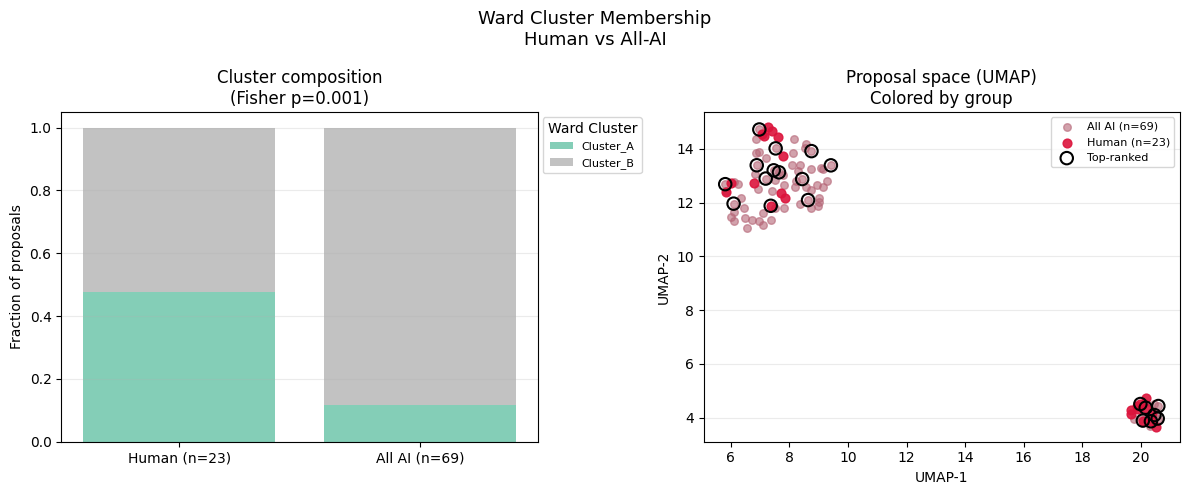

Saved cluster_membership_human_vs_allai.png


In [60]:
if topic_cluster_df is None:
    print('WARNING: topic_cluster_df not loaded — skipping Analysis 1.3')
    ward_labels_full = None
else:
    tc_ward = topic_cluster_df.merge(
        proposal_meta[['title', 'group_binary', 'group_model']], on='title', how='left')
    tc_ward['group_binary'] = tc_ward['group_binary'].fillna('AI')

    ward_col = 'ward_cluster_name' if 'ward_cluster_name' in tc_ward.columns else 'ward_cluster_display'
    if ward_col not in tc_ward.columns:
        ward_col = None
        print('WARNING: ward cluster column not found')

    if ward_col:
        human_w = tc_ward[tc_ward['group_binary'] == 'Human']
        ai_w    = tc_ward[tc_ward['group_binary'] == 'AI']
        clusters = sorted(tc_ward[ward_col].unique())

        # 2x2 contingency (Human / AI) x (Cluster A / Cluster B)
        if len(clusters) == 2:
            ct_ward = np.array([
                [(human_w[ward_col] == clusters[0]).sum(), (human_w[ward_col] == clusters[1]).sum()],
                [(ai_w[ward_col] == clusters[0]).sum(),    (ai_w[ward_col] == clusters[1]).sum()]
            ])
            odds, p_fisher = fisher_exact(ct_ward)
            print(f'Ward cluster Fisher exact: OR={odds:.3f}, p={p_fisher:.4f} ({fmt_p(p_fisher)})')
        else:
            chi2_w, p_fisher, _, _ = chi2_contingency(
                np.array([[(human_w[ward_col] == c).sum() for c in clusters],
                           [(ai_w[ward_col] == c).sum() for c in clusters]]))
            print(f'Ward cluster chi2={chi2_w:.3f}, p={p_fisher:.4f}')

        clust_rows = []
        for c in clusters:
            clust_rows.append({
                'cluster': c,
                'human_count': (human_w[ward_col] == c).sum(),
                'ai_count':    (ai_w[ward_col] == c).sum(),
                'human_frac':  (human_w[ward_col] == c).mean(),
                'ai_frac':     (ai_w[ward_col] == c).mean(),
                'fisher_p':    float(p_fisher),
            })
        clust_df = pd.DataFrame(clust_rows)
        clust_df.to_csv(TABLES_DIR_AI / 'cluster_membership_human_vs_allai.csv', index=False)

        # Copy supplementary per-model CSV
        import shutil
        _src = TABLES_DIR / 'diversity_cluster_membership_by_group.csv'
        if _src.exists():
            shutil.copy(_src, TABLES_DIR_AI / 'supplementary_cluster_membership_by_model.csv')

        # ── Figure ──────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Ward Cluster Membership\nHuman vs All-AI', fontsize=13)

        # Panel A: stacked bar
        ax = axes[0]
        group_names = [f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})']
        clust_colors = plt.cm.Set2(np.linspace(0, 1, len(clusters)))
        bottoms = np.zeros(2)
        for ci, (c, cc) in enumerate(zip(clusters, clust_colors)):
            vals = np.array([
                (human_w[ward_col] == c).mean(),
                (ai_w[ward_col] == c).mean()
            ])
            ax.bar([0, 1], vals, bottom=bottoms, color=cc, label=str(c), alpha=0.8)
            bottoms += vals
        ax.set_xticks([0, 1])
        ax.set_xticklabels(group_names)
        ax.set_ylabel('Fraction of proposals')
        ax.set_title(f'Cluster composition\n(Fisher p={p_fisher:.3f})')
        ax.legend(title='Ward Cluster', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)
        ax.yaxis.grid(True, alpha=0.25)

        # Panel B: UMAP scatter by binary group
        ax2 = axes[1]
        ax2.scatter(X_umap2d[ai_idx, 0], X_umap2d[ai_idx, 1],
                    c=AI_COLOR, s=30, alpha=0.6, label=f'All AI (n={len(ai_idx)})', zorder=3)
        ax2.scatter(X_umap2d[human_idx, 0], X_umap2d[human_idx, 1],
                    c=HUMAN_COLOR, s=40, alpha=0.9, label=f'Human (n={len(human_idx)})', zorder=4)
        # Top-ranked with black ring
        top_mask = proposal_meta['is_top5_ranked'].fillna(False).astype(bool)
        top_idx_arr = proposal_meta.index[top_mask].to_numpy()
        if len(top_idx_arr) > 0:
            ax2.scatter(X_umap2d[top_idx_arr, 0], X_umap2d[top_idx_arr, 1],
                        s=80, facecolors='none', edgecolors='black', linewidths=1.5,
                        zorder=5, label='Top-ranked')
        ax2.set_xlabel('UMAP-1')
        ax2.set_ylabel('UMAP-2')
        ax2.set_title('Proposal space (UMAP)\nColored by group')
        ax2.legend(fontsize=8)
        ax2.yaxis.grid(True, alpha=0.25)

        plt.tight_layout()
        fig.savefig(FIGURES_DIR_AI / 'cluster_membership_human_vs_allai.png',
                    dpi=200, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print('Saved cluster_membership_human_vs_allai.png')
        ward_labels_full = tc_ward[ward_col].values


## Analysis 1.4: GMM Segregation (Human vs AI)

In [61]:
if master_df is None:
    print('WARNING: master_df not loaded — using D_pp for distance analysis only')

# Within/between group mean distances
D_hh = D_pp[np.ix_(human_idx, human_idx)].copy()
np.fill_diagonal(D_hh, np.nan)
D_aa = D_pp[np.ix_(ai_idx, ai_idx)].copy()
np.fill_diagonal(D_aa, np.nan)
D_ha = D_pp[np.ix_(human_idx, ai_idx)]

within_human_mean = float(np.nanmean(D_hh))
within_ai_mean    = float(np.nanmean(D_aa))
between_mean      = float(np.nanmean(D_ha))
bw_ratio          = between_mean / np.mean([within_human_mean, within_ai_mean])
print(f'Within-Human mean dist: {within_human_mean:.4f}')
print(f'Within-AI mean dist:    {within_ai_mean:.4f}')
print(f'Between-group mean dist: {between_mean:.4f}')
print(f'Between/Within ratio:   {bw_ratio:.4f}')

# Permutation test for between/within ratio
rng_gmm = np.random.default_rng(45)
all_idx_arr = np.concatenate([human_idx, ai_idx])
obs_ratio = bw_ratio
perm_ratios = []
for _ in range(2000):
    perm_all = rng_gmm.permutation(all_idx_arr)
    ph = perm_all[:len(human_idx)]
    pa = perm_all[len(human_idx):]
    d_hh_p = D_pp[np.ix_(ph, ph)].copy(); np.fill_diagonal(d_hh_p, np.nan)
    d_aa_p = D_pp[np.ix_(pa, pa)].copy(); np.fill_diagonal(d_aa_p, np.nan)
    d_ha_p = D_pp[np.ix_(ph, pa)]
    w_mean_p = np.mean([np.nanmean(d_hh_p), np.nanmean(d_aa_p)])
    b_mean_p = np.nanmean(d_ha_p)
    perm_ratios.append(b_mean_p / w_mean_p if w_mean_p > 0 else np.nan)
perm_ratios = np.array([v for v in perm_ratios if np.isfinite(v)])
p_perm_bw = (np.sum(np.abs(perm_ratios - 1) >= abs(obs_ratio - 1)) + 1) / (len(perm_ratios) + 1)
print(f'B/W ratio permutation p={p_perm_bw:.4f} ({fmt_p(p_perm_bw)})')

# NMI / ARI with GMM labels (if available)
nmi_val, ari_val = np.nan, np.nan
if master_df is not None and 'remote_clique_group' in master_df.columns:
    # Use any cluster column available
    cluster_col = None
    for cc in ['gmm_cluster', 'remote_clique_group', 'ward_cluster']:
        if cc in master_df.columns:
            cluster_col = cc
            break
    if cluster_col:
        true_labels = (proposal_meta['group_binary'] == 'AI').astype(int).values
        pred_labels = master_df[cluster_col].values
        le = LabelEncoder()
        pred_enc = le.fit_transform(pred_labels)
        nmi_val = normalized_mutual_info_score(true_labels, pred_enc)
        ari_val = adjusted_rand_score(true_labels, pred_enc)
        print(f'NMI={nmi_val:.4f}, ARI={ari_val:.4f}')

gmm_seg = pd.DataFrame([{
    'within_human_mean': within_human_mean,
    'within_ai_mean': within_ai_mean,
    'between_mean': between_mean,
    'bw_ratio': bw_ratio,
    'perm_p_bw_ratio': p_perm_bw,
    'nmi': nmi_val,
    'ari': ari_val,
}])
gmm_seg.to_csv(TABLES_DIR_AI / 'gmm_segregation_human_vs_allai.csv', index=False)
print('Saved gmm_segregation_human_vs_allai.csv')


Within-Human mean dist: 0.4429
Within-AI mean dist:    0.1826
Between-group mean dist: 0.3880
Between/Within ratio:   1.2406
B/W ratio permutation p=0.0035 (**)
NMI=0.5772, ARI=0.3259
Saved gmm_segregation_human_vs_allai.csv


# PART II: DIVERSITY

Three-value reporting pattern for N-sensitive metrics:
- `human_metric`: human group value (n=23)
- `ai_full_metric`: all-AI value (n=69, supplementary)
- `ai_boot_mean±CI`: bootstrap-corrected (n=23-equivalent, primary)

## Analysis 2.1: Within-Group Pairwise Diversity

In [62]:
# Per-proposal pairwise mean distances
human_pp = per_proposal_pairwise(human_idx, D_pp)
ai_full_pp = per_proposal_pairwise(ai_idx, D_pp)

# Group-level metric
human_mpd    = group_mean_pairwise(human_idx, D_pp)
ai_full_mpd  = group_mean_pairwise(ai_idx, D_pp)

# Bootstrap subsamples
boot_mpd_vals = boot_metric_over_samples(group_mean_pairwise, boot_ai_idx_samples, D_pp)
ai_boot_mpd   = float(np.mean(boot_mpd_vals))
ai_boot_mpd_ci = boot_ci(boot_mpd_vals)

# Per-model supplementary
claude_mpd = group_mean_pairwise(claude_idx, D_pp)
gemini_mpd = group_mean_pairwise(gemini_idx, D_pp)
gpt_mpd    = group_mean_pairwise(gpt_idx, D_pp)
within_model_avg = float(np.mean([claude_mpd, gemini_mpd, gpt_mpd]))

# MW test on per-proposal values (full 23 vs 69)
stat_pp, p_mw = mannwhitneyu(ai_full_pp, human_pp, alternative='two-sided')
delta    = cliffs_delta(ai_full_pp, human_pp)
d_lo, d_hi = bootstrap_cliffs_delta_ci(ai_full_pp, human_pp, n_boot=2000, random_state=42)

# Permutation test on per-proposal values (full groups)
rng_perm_pp = np.random.default_rng(42)
all_pp_vals = np.concatenate([human_pp, ai_full_pp])
obs_mean_diff = np.mean(ai_full_pp) - np.mean(human_pp)
perm_diffs_pp = []
for _ in range(10000):
    perm = rng_perm_pp.permutation(all_pp_vals)
    perm_diffs_pp.append(np.mean(perm[len(human_pp):]) - np.mean(perm[:len(human_pp)]))
p_perm_pp = (np.sum(np.abs(perm_diffs_pp) >= abs(obs_mean_diff)) + 1) / 10001

print(f'Human MPD:       {human_mpd:.4f}')
print(f'AI Full MPD:     {ai_full_mpd:.4f} (n=69)')
print(f'AI Boot MPD:     {ai_boot_mpd:.4f} [{ai_boot_mpd_ci[0]:.4f}, {ai_boot_mpd_ci[1]:.4f}] (n=23-equiv)')
print(f'Within-model avg: {within_model_avg:.4f}')
print(f"MW p={p_mw:.4f}, Perm p={p_perm_pp:.4f}, Cliff's d={delta:.3f} [{d_lo:.3f},{d_hi:.3f}]")

summary_pp = {
    'human_mpd': human_mpd, 'ai_full_mpd': ai_full_mpd,
    'ai_boot_mpd_mean': ai_boot_mpd,
    'ai_boot_ci_lo': ai_boot_mpd_ci[0], 'ai_boot_ci_hi': ai_boot_mpd_ci[1],
    'within_model_avg': within_model_avg,
    'mw_p': p_mw, 'perm_p': p_perm_pp,
    'cliffs_delta': delta, 'cliffs_delta_ci_lo': d_lo, 'cliffs_delta_ci_hi': d_hi
}
pd.DataFrame([summary_pp]).to_csv(
    TABLES_DIR_AI / 'diversity_pairwise_human_vs_allai.csv', index=False)


Human MPD:       0.4429
AI Full MPD:     0.1826 (n=69)
AI Boot MPD:     0.1824 [0.0390, 0.2900] (n=23-equiv)
Within-model avg: 0.1663
MW p=0.0000, Perm p=0.0001, Cliff's d=-0.768 [-0.913,-0.623]


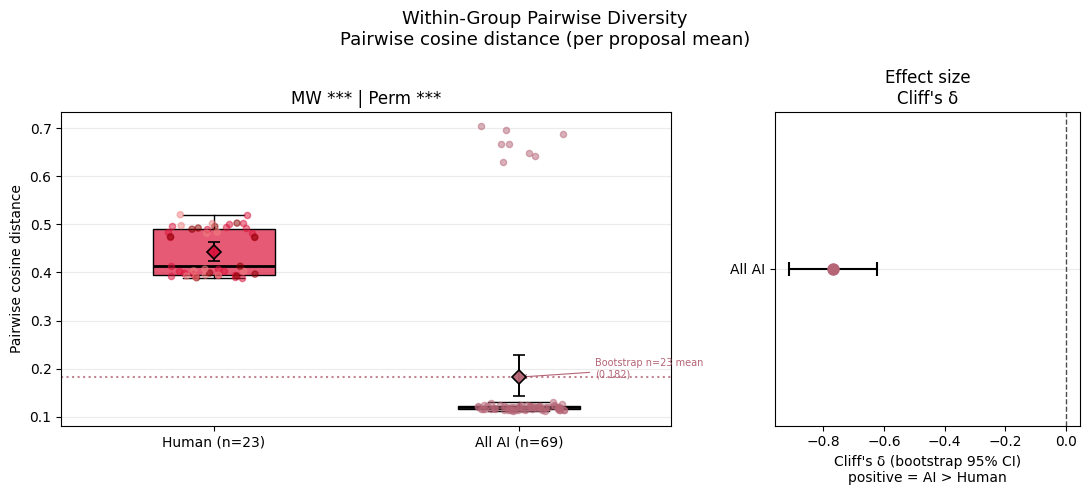

Saved pairwise_diversity_human_vs_allai.png


In [63]:
# Analysis 2.1 figure: boxplot + forest plot
fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Within-Group Pairwise Diversity\nPairwise cosine distance (per proposal mean)',
             fontsize=13)

# Determine human point colors by funding
if 'human_color_shade' in proposal_meta.columns:
    h_colors = proposal_meta.loc[human_idx, 'human_color_shade'].values
elif 'funding' in proposal_meta.columns:
    h_colors = np.where(
        proposal_meta.loc[human_idx, 'funding'].fillna('').str.lower() == 'funded',
        HUMAN_FUNDED_COLOR, HUMAN_NONFUNDED_COLOR)
else:
    h_colors = np.full(len(human_idx), HUMAN_COLOR)

# Panel A: boxplot with jitter + mean CI diamonds
ax_a = axes[0]
h_data = human_pp
a_data = ai_full_pp
group_data = [h_data, a_data]
group_colors_box = [HUMAN_COLOR, AI_COLOR]
xlabels = [f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})']
draw_boxplot_with_jitter(ax_a, group_data, xlabels, group_colors_box)

# Add human points colored by funding
rng_j2 = np.random.default_rng(1)
xs_h = rng_j2.uniform(-0.15, 0.15, size=len(h_data))
ax_a.scatter(xs_h, h_data, s=20, c=h_colors, alpha=0.5, zorder=6)

# Annotate bootstrap mean for AI
ax_a.axhline(ai_boot_mpd, color=AI_COLOR, linewidth=1.5, linestyle=':', alpha=0.8)
ax_a.annotate(f'Bootstrap n=23 mean\n({ai_boot_mpd:.3f})',
               xy=(1, ai_boot_mpd), xytext=(1.25, ai_boot_mpd),
               fontsize=7, color=AI_COLOR,
               arrowprops=dict(arrowstyle='->', color=AI_COLOR, lw=0.8))
ax_a.set_ylabel('Pairwise cosine distance')
ax_a.set_title(f'MW {fmt_p(p_mw)} | Perm {fmt_p(p_perm_pp)}')

# Panel B: Cliff's delta forest plot
ax_b = axes[1]
draw_effect_size_panel(ax_b, delta, d_lo, d_hi, label='All AI', p_val=p_perm_pp)
ax_b.set_title("Effect size\nCliff's δ")

plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'pairwise_diversity_human_vs_allai.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved pairwise_diversity_human_vs_allai.png')


## Analysis 2.1b: Pairwise Distance Bimodality (Decomposed)

human: dip=0.1420, p=0.0000
ai_all: dip=0.0850, p=0.0000
within_model: dip=0.0765, p=0.0000
between_model: dip=0.0894, p=0.0000


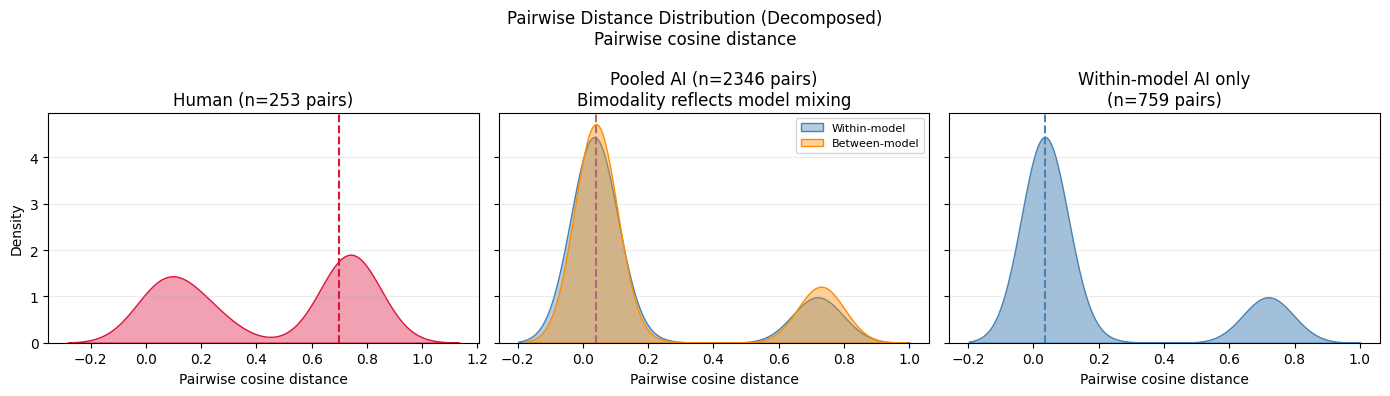

Saved pairwise_diversity_bimodality_decomposed.png


In [64]:
# Extract pairwise distance distributions
def _upper_tri(D, idx):
    Dg = D[np.ix_(idx, idx)]
    iu = np.triu_indices(len(idx), k=1)
    return Dg[iu]

human_pairs = _upper_tri(D_pp, human_idx)
ai_pairs_all = _upper_tri(D_pp, ai_idx)

# Within-model pairs
within_model_pairs = np.concatenate([
    _upper_tri(D_pp, claude_idx),
    _upper_tri(D_pp, gemini_idx),
    _upper_tri(D_pp, gpt_idx)
])

# Between-model pairs
between_model_pairs = []
for m1, m2 in [(claude_idx, gemini_idx), (claude_idx, gpt_idx), (gemini_idx, gpt_idx)]:
    Dcm = D_pp[np.ix_(m1, m2)]
    between_model_pairs.append(Dcm.ravel())
between_model_pairs = np.concatenate(between_model_pairs)

# Diptest (optional)
dip_results = {}
try:
    from diptest import diptest
    for name, vals in [('human', human_pairs), ('ai_all', ai_pairs_all),
                        ('within_model', within_model_pairs),
                        ('between_model', between_model_pairs)]:
        d_stat, d_p = diptest(vals)
        dip_results[name] = {'dip_stat': d_stat, 'dip_p': d_p}
        print(f'{name}: dip={d_stat:.4f}, p={d_p:.4f}')
except ImportError:
    print('diptest not installed — skipping Hartigan dip test')
    for name in ['human', 'ai_all', 'within_model', 'between_model']:
        dip_results[name] = {'dip_stat': np.nan, 'dip_p': np.nan}

bimod_df = pd.DataFrame([
    {'group': k, **v,
     'n_pairs': len([human_pairs, ai_pairs_all, within_model_pairs, between_model_pairs][i]),
     'median_dist': np.median([human_pairs, ai_pairs_all, within_model_pairs, between_model_pairs][i])}
    for i, (k, v) in enumerate(dip_results.items())
])
bimod_df.to_csv(TABLES_DIR_AI / 'diversity_pairwise_bimodality_decomposed.csv', index=False)

# Figure: 3-panel KDE
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('Pairwise Distance Distribution (Decomposed)\nPairwise cosine distance', fontsize=12)

ax1 = axes[0]
sns.kdeplot(human_pairs, ax=ax1, color=HUMAN_COLOR, fill=True, alpha=0.4)
ax1.axvline(np.median(human_pairs), color=HUMAN_COLOR, ls='--', lw=1.5)
ax1.set_title(f'Human (n={len(human_pairs)} pairs)')
ax1.set_xlabel('Pairwise cosine distance')
ax1.yaxis.grid(True, alpha=0.25)

ax2 = axes[1]
sns.kdeplot(within_model_pairs, ax=ax2, color='steelblue', fill=True, alpha=0.4,
            label='Within-model')
sns.kdeplot(between_model_pairs, ax=ax2, color='darkorange', fill=True, alpha=0.4,
            label='Between-model')
ax2.axvline(np.median(ai_pairs_all), color=AI_COLOR, ls='--', lw=1.5)
ax2.set_title(f'Pooled AI (n={len(ai_pairs_all)} pairs)\n'
              'Bimodality reflects model mixing')
ax2.set_xlabel('Pairwise cosine distance')
ax2.legend(fontsize=8)
ax2.yaxis.grid(True, alpha=0.25)

ax3 = axes[2]
sns.kdeplot(within_model_pairs, ax=ax3, color='steelblue', fill=True, alpha=0.5)
ax3.axvline(np.median(within_model_pairs), color='steelblue', ls='--', lw=1.5)
ax3.set_title(f'Within-model AI only\n(n={len(within_model_pairs)} pairs)')
ax3.set_xlabel('Pairwise cosine distance')
ax3.yaxis.grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'pairwise_diversity_bimodality_decomposed.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved pairwise_diversity_bimodality_decomposed.png')


## Analysis 2.1c: Cross-Group Topic Space Alignment

In [65]:
ai_to_nearest_human  = np.array([np.min(D_pp[i, human_idx]) for i in ai_idx])
human_to_nearest_ai  = np.array([np.min(D_pp[j, ai_idx]) for j in human_idx])

stat_cross, p_cross = mannwhitneyu(ai_to_nearest_human, human_to_nearest_ai,
                                    alternative='two-sided')
delta_cross = cliffs_delta(ai_to_nearest_human, human_to_nearest_ai)
d_lo_c, d_hi_c = bootstrap_cliffs_delta_ci(ai_to_nearest_human, human_to_nearest_ai)

print(f'AI-to-nearest-Human: mean={np.mean(ai_to_nearest_human):.4f}')
print(f'Human-to-nearest-AI: mean={np.mean(human_to_nearest_ai):.4f}')
print(f"MW p={p_cross:.4f} ({fmt_p(p_cross)}), Cliff's d={delta_cross:.3f}")

pd.DataFrame([{
    'ai_to_nearest_human_mean': float(np.mean(ai_to_nearest_human)),
    'human_to_nearest_ai_mean': float(np.mean(human_to_nearest_ai)),
    'mw_p': p_cross, 'cliffs_delta': delta_cross,
    'cliffs_delta_ci_lo': d_lo_c, 'cliffs_delta_ci_hi': d_hi_c
}]).to_csv(TABLES_DIR_AI / 'diversity_cross_group_alignment_human_vs_allai.csv', index=False)


AI-to-nearest-Human: mean=0.0410
Human-to-nearest-AI: mean=0.0756
MW p=0.0308 (*), Cliff's d=-0.302


## Analysis 2.1d: Within-Cluster Diversity

In [66]:
if topic_cluster_df is None:
    print('WARNING: topic_cluster_df not loaded — skipping Analysis 2.1d')
else:
    tc_c = topic_cluster_df.merge(
        proposal_meta[['title', 'group_binary']], on='title', how='left')
    tc_c['group_binary'] = tc_c['group_binary'].fillna('AI')
    ward_col2 = 'ward_cluster_name' if 'ward_cluster_name' in tc_c.columns else 'ward_cluster_display'

    if ward_col2 not in tc_c.columns:
        print('WARNING: ward cluster column not found')
    else:
        wc_rows = []
        clusters_wc = sorted(tc_c[ward_col2].unique())
        for cname in clusters_wc:
            titles_in_cluster = tc_c[tc_c[ward_col2] == cname]['title'].values
            # find indices
            idx_in_cluster = proposal_meta.index[
                proposal_meta['title'].isin(titles_in_cluster)].to_numpy()
            h_in = np.intersect1d(idx_in_cluster, human_idx)
            a_in = np.intersect1d(idx_in_cluster, ai_idx)
            row = {'cluster': cname, 'n_human': len(h_in), 'n_ai': len(a_in),
                   'human_mpd': np.nan, 'ai_mpd': np.nan, 'mw_p': np.nan}
            if len(h_in) >= 3 and len(a_in) >= 3:
                h_pp_c = per_proposal_pairwise(h_in, D_pp)
                a_pp_c = per_proposal_pairwise(a_in, D_pp)
                row['human_mpd'] = float(np.nanmean(h_pp_c))
                row['ai_mpd']    = float(np.nanmean(a_pp_c))
                _, row['mw_p']   = mannwhitneyu(a_pp_c, h_pp_c, alternative='two-sided')
            wc_rows.append(row)
        wc_df = pd.DataFrame(wc_rows)
        wc_df.to_csv(TABLES_DIR_AI / 'diversity_within_cluster_human_vs_allai.csv', index=False)
        print(wc_df.to_string())


     cluster  n_human  n_ai  human_mpd    ai_mpd          mw_p
0  Cluster_A       11     8   0.192414  0.152170  9.102696e-03
1  Cluster_B       12    61   0.054159  0.037952  6.835410e-08


## Analysis 2.2a: Centroid Dispersion (LOO)

Human LOO mean:     0.2665
AI Full LOO mean:   0.0968 (n=69)
AI Boot LOO mean:   0.0991 [0.0206, 0.1626]
MW p=0.0000, Perm p=0.0004, Cliff's d=-0.768


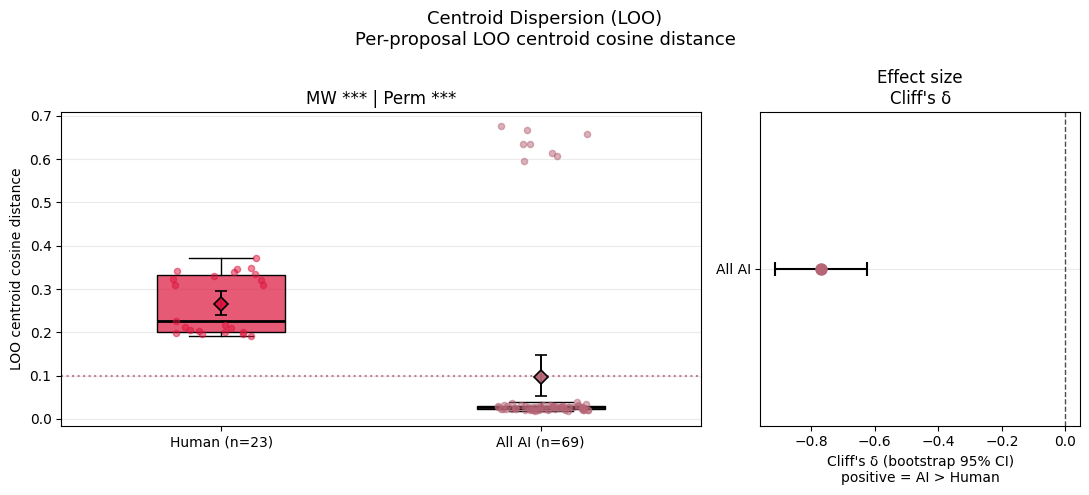

Saved centroid_dispersion_human_vs_allai.png


In [67]:
# Per-proposal LOO centroid distances
human_loo    = per_proposal_loo_centroid(human_idx, X_prop)
ai_full_loo  = per_proposal_loo_centroid(ai_idx, X_prop)

human_loo_mean   = float(np.mean(human_loo))
ai_full_loo_mean = float(np.mean(ai_full_loo))

boot_loo_vals = boot_metric_over_samples(
    lambda s, X: float(np.mean(group_loo_centroid(s, X))),
    boot_ai_idx_samples, X_prop
)
ai_boot_loo_mean = float(np.mean(boot_loo_vals))
ai_boot_loo_ci   = boot_ci(boot_loo_vals)

human_span90       = float(np.percentile(human_loo, 90))
boot_span90_vals   = boot_metric_over_samples(
    lambda s, X: float(np.percentile(group_loo_centroid(s, X), 90)),
    boot_ai_idx_samples, X_prop
)
ai_boot_span90_mean = float(np.mean(boot_span90_vals))

stat_loo, p_mw_loo = mannwhitneyu(ai_full_loo, human_loo, alternative='two-sided')
delta_loo = cliffs_delta(ai_full_loo, human_loo)
d_lo_loo, d_hi_loo = bootstrap_cliffs_delta_ci(ai_full_loo, human_loo, n_boot=2000, random_state=42)

rng_perm_loo = np.random.default_rng(43)
all_loo_vals = np.concatenate([human_loo, ai_full_loo])
obs_diff_loo = np.mean(ai_full_loo) - np.mean(human_loo)
perm_diffs_loo = []
for _ in range(10000):
    p_perm_arr = rng_perm_loo.permutation(all_loo_vals)
    perm_diffs_loo.append(np.mean(p_perm_arr[len(human_loo):]) - np.mean(p_perm_arr[:len(human_loo)]))
p_perm_loo = (np.sum(np.abs(perm_diffs_loo) >= abs(obs_diff_loo)) + 1) / 10001

print(f'Human LOO mean:     {human_loo_mean:.4f}')
print(f'AI Full LOO mean:   {ai_full_loo_mean:.4f} (n=69)')
print(f'AI Boot LOO mean:   {ai_boot_loo_mean:.4f} [{ai_boot_loo_ci[0]:.4f}, {ai_boot_loo_ci[1]:.4f}]')
print(f"MW p={p_mw_loo:.4f}, Perm p={p_perm_loo:.4f}, Cliff's d={delta_loo:.3f}")

pd.DataFrame([{
    'human_loo_mean': human_loo_mean, 'ai_full_loo_mean': ai_full_loo_mean,
    'ai_boot_loo_mean': ai_boot_loo_mean,
    'ai_boot_loo_ci_lo': ai_boot_loo_ci[0], 'ai_boot_loo_ci_hi': ai_boot_loo_ci[1],
    'human_span90': human_span90, 'ai_boot_span90_mean': ai_boot_span90_mean,
    'mw_p': p_mw_loo, 'perm_p': p_perm_loo,
    'cliffs_delta': delta_loo, 'cliffs_delta_ci_lo': d_lo_loo, 'cliffs_delta_ci_hi': d_hi_loo
}]).to_csv(TABLES_DIR_AI / 'diversity_centroid_human_vs_allai.csv', index=False)

# Figure
fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Centroid Dispersion (LOO)\nPer-proposal LOO centroid cosine distance', fontsize=13)
draw_boxplot_with_jitter(axes[0],
    [human_loo, ai_full_loo],
    [f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})'],
    [HUMAN_COLOR, AI_COLOR])
axes[0].axhline(ai_boot_loo_mean, color=AI_COLOR, linewidth=1.5, linestyle=':', alpha=0.8)
axes[0].set_ylabel('LOO centroid cosine distance')
axes[0].set_title(f'MW {fmt_p(p_mw_loo)} | Perm {fmt_p(p_perm_loo)}')
draw_effect_size_panel(axes[1], delta_loo, d_lo_loo, d_hi_loo, p_val=p_perm_loo)
axes[1].set_title("Effect size\nCliff's δ")
plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'centroid_dispersion_human_vs_allai.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved centroid_dispersion_human_vs_allai.png')


## Analysis 2.2b: Global-Centroid Distance

In [68]:
human_gc   = group_global_centroid(human_idx, X_prop)
ai_full_gc = group_global_centroid(ai_idx, X_prop)

boot_gc_vals   = boot_metric_over_samples(
    lambda s, X: float(np.mean(group_global_centroid(s, X))),
    boot_ai_idx_samples, X_prop
)
ai_boot_gc_mean = float(np.mean(boot_gc_vals))
ai_boot_gc_ci   = boot_ci(boot_gc_vals)

stat_gc, p_mw_gc = mannwhitneyu(ai_full_gc, human_gc, alternative='two-sided')
delta_gc = cliffs_delta(ai_full_gc, human_gc)
d_lo_gc, d_hi_gc = bootstrap_cliffs_delta_ci(ai_full_gc, human_gc)

rng_gc = np.random.default_rng(46)
all_gc = np.concatenate([human_gc, ai_full_gc])
obs_gc = np.mean(ai_full_gc) - np.mean(human_gc)
perm_gc = []
for _ in range(10000):
    p_arr = rng_gc.permutation(all_gc)
    perm_gc.append(np.mean(p_arr[len(human_gc):]) - np.mean(p_arr[:len(human_gc)]))
p_perm_gc = (np.sum(np.abs(perm_gc) >= abs(obs_gc)) + 1) / 10001

print(f'Human global centroid mean:     {np.mean(human_gc):.4f}')
print(f'AI Full global centroid mean:   {np.mean(ai_full_gc):.4f}')
print(f'AI Boot mean: {ai_boot_gc_mean:.4f} [{ai_boot_gc_ci[0]:.4f}, {ai_boot_gc_ci[1]:.4f}]')
print(f"MW p={p_mw_gc:.4f} ({fmt_p(p_mw_gc)}), Perm p={p_perm_gc:.4f} ({fmt_p(p_perm_gc)})")

pd.DataFrame([{
    'human_gc_mean': float(np.mean(human_gc)), 'ai_full_gc_mean': float(np.mean(ai_full_gc)),
    'ai_boot_gc_mean': ai_boot_gc_mean,
    'ai_boot_gc_ci_lo': ai_boot_gc_ci[0], 'ai_boot_gc_ci_hi': ai_boot_gc_ci[1],
    'mw_p': p_mw_gc, 'perm_p': p_perm_gc,
    'cliffs_delta': delta_gc, 'cliffs_delta_ci_lo': d_lo_gc, 'cliffs_delta_ci_hi': d_hi_gc
}]).to_csv(TABLES_DIR_AI / 'diversity_global_centroid_human_vs_allai.csv', index=False)


Human global centroid mean:     0.2926
AI Full global centroid mean:   0.0991
AI Boot mean: 0.0989 [0.0416, 0.1516]
MW p=0.0000 (***), Perm p=0.0001 (***)


## Analysis 2.2c: MST Dispersion

Human MST mean edge: 0.1126
AI Full MST mean edge: 0.0427 (n=69)
AI Boot MST mean: 0.0638 [0.0272, 0.0767]
Observed diff=-0.0699, Perm p=0.0002 (***)


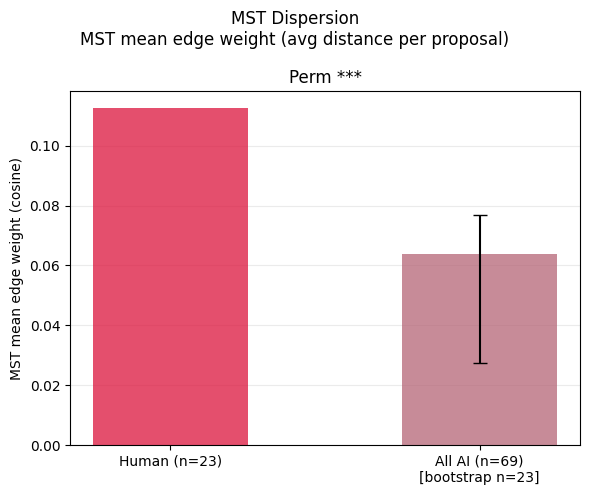

Saved diversity_mst_human_vs_allai.png


In [69]:
human_mst   = group_mst_dispersion(human_idx, D_pp)
ai_full_mst = group_mst_dispersion(ai_idx, D_pp)

boot_mst_vals   = boot_metric_over_samples(group_mst_dispersion, boot_ai_idx_samples, D_pp)
ai_boot_mst_mean = float(np.mean(boot_mst_vals))
ai_boot_mst_ci   = boot_ci(boot_mst_vals)

# Permutation test (group-level, permute binary label)
rng_mst = np.random.default_rng(44)
all_idx_mst = np.concatenate([human_idx, ai_idx])
obs_mst_diff = ai_full_mst - human_mst
perm_mst_diffs = []
for _ in range(5000):
    perm = rng_mst.permutation(all_idx_mst)
    h_perm = perm[:len(human_idx)]
    a_perm = perm[len(human_idx):]
    perm_mst_diffs.append(
        group_mst_dispersion(a_perm, D_pp) - group_mst_dispersion(h_perm, D_pp))
perm_mst_diffs = np.array(perm_mst_diffs)
p_perm_mst = (np.sum(np.abs(perm_mst_diffs) >= abs(obs_mst_diff)) + 1) / 5001

print(f'Human MST mean edge: {human_mst:.4f}')
print(f'AI Full MST mean edge: {ai_full_mst:.4f} (n=69)')
print(f'AI Boot MST mean: {ai_boot_mst_mean:.4f} [{ai_boot_mst_ci[0]:.4f}, {ai_boot_mst_ci[1]:.4f}]')
print(f'Observed diff={obs_mst_diff:.4f}, Perm p={p_perm_mst:.4f} ({fmt_p(p_perm_mst)})')

pd.DataFrame([{
    'human_mst': human_mst, 'ai_full_mst': ai_full_mst,
    'ai_boot_mst_mean': ai_boot_mst_mean,
    'ai_boot_mst_ci_lo': ai_boot_mst_ci[0], 'ai_boot_mst_ci_hi': ai_boot_mst_ci[1],
    'obs_diff': obs_mst_diff, 'perm_p': p_perm_mst
}]).to_csv(TABLES_DIR_AI / 'diversity_mst_human_vs_allai.csv', index=False)

# Figure: bar chart
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('MST Dispersion\nMST mean edge weight (avg distance per proposal)', fontsize=12)
bar_vals = [human_mst, ai_boot_mst_mean]
bar_errs = [0, (ai_boot_mst_ci[1] - ai_boot_mst_ci[0]) / 2]
bars = ax.bar([0, 1], bar_vals, color=[HUMAN_COLOR, AI_COLOR], alpha=0.75, width=0.5)
ax.errorbar(1, ai_boot_mst_mean,
            yerr=[[ai_boot_mst_mean - ai_boot_mst_ci[0]],
                  [ai_boot_mst_ci[1] - ai_boot_mst_mean]],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})\n[bootstrap n=23]'])
ax.set_ylabel('MST mean edge weight (cosine)')
ax.set_title(f'Perm {fmt_p(p_perm_mst)}')
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'diversity_mst_human_vs_allai.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved diversity_mst_human_vs_allai.png')


## Analysis 2.2d: Sparseness (Medoid-Based Dispersion)

Human sparseness: 0.3721
AI Full sparseness: 0.1098
AI Boot: 0.1098 [0.0308, 0.1813]
MW p=0.0000, Perm p=0.0002, Cliff's d=-0.742


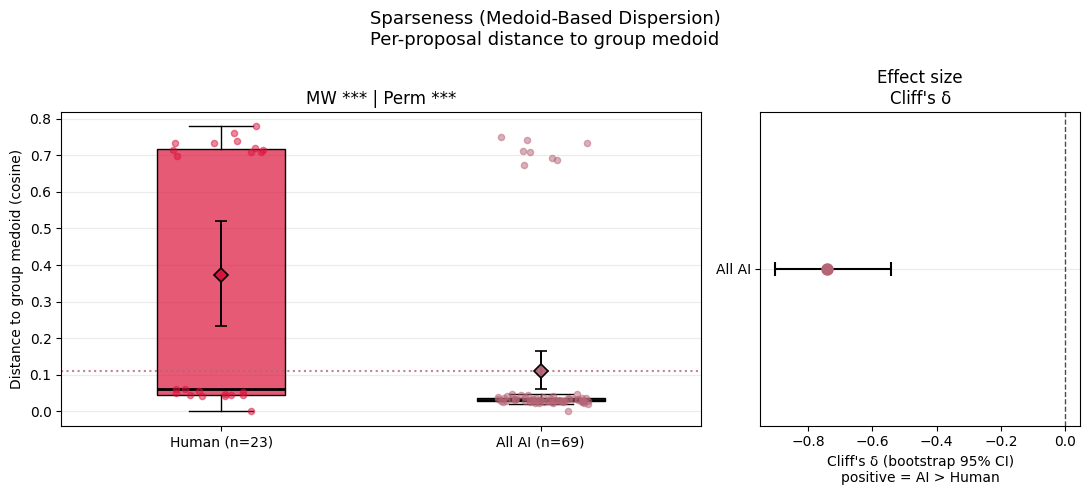

Saved diversity_sparseness_human_vs_allai.png


In [70]:
human_spar   = group_sparseness(human_idx, D_pp)
ai_full_spar = group_sparseness(ai_idx, D_pp)

boot_spar_vals   = boot_metric_over_samples(group_sparseness, boot_ai_idx_samples, D_pp)
ai_boot_spar_mean = float(np.mean(boot_spar_vals))
ai_boot_spar_ci   = boot_ci(boot_spar_vals)

# Per-proposal medoid distances for MW
human_med_d  = per_proposal_medoid_dist(human_idx, D_pp)
ai_full_med_d = per_proposal_medoid_dist(ai_idx, D_pp)
stat_spar, p_mw_spar = mannwhitneyu(ai_full_med_d, human_med_d, alternative='two-sided')
delta_spar = cliffs_delta(ai_full_med_d, human_med_d)
d_lo_spar, d_hi_spar = bootstrap_cliffs_delta_ci(ai_full_med_d, human_med_d)

# Permutation on per-proposal values
rng_spar = np.random.default_rng(47)
all_spar = np.concatenate([human_med_d, ai_full_med_d])
obs_spar = np.mean(ai_full_med_d) - np.mean(human_med_d)
perm_spar = []
for _ in range(10000):
    p_arr = rng_spar.permutation(all_spar)
    perm_spar.append(np.mean(p_arr[len(human_med_d):]) - np.mean(p_arr[:len(human_med_d)]))
p_perm_spar = (np.sum(np.abs(perm_spar) >= abs(obs_spar)) + 1) / 10001

print(f'Human sparseness: {human_spar:.4f}')
print(f'AI Full sparseness: {ai_full_spar:.4f}')
print(f'AI Boot: {ai_boot_spar_mean:.4f} [{ai_boot_spar_ci[0]:.4f}, {ai_boot_spar_ci[1]:.4f}]')
print(f"MW p={p_mw_spar:.4f}, Perm p={p_perm_spar:.4f}, Cliff's d={delta_spar:.3f}")

pd.DataFrame([{
    'human_sparseness': human_spar, 'ai_full_sparseness': ai_full_spar,
    'ai_boot_spar_mean': ai_boot_spar_mean,
    'ai_boot_spar_ci_lo': ai_boot_spar_ci[0], 'ai_boot_spar_ci_hi': ai_boot_spar_ci[1],
    'mw_p': p_mw_spar, 'perm_p': p_perm_spar,
    'cliffs_delta': delta_spar, 'cliffs_delta_ci_lo': d_lo_spar, 'cliffs_delta_ci_hi': d_hi_spar
}]).to_csv(TABLES_DIR_AI / 'diversity_sparseness_human_vs_allai.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Sparseness (Medoid-Based Dispersion)\nPer-proposal distance to group medoid', fontsize=13)
draw_boxplot_with_jitter(axes[0],
    [human_med_d, ai_full_med_d],
    [f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})'],
    [HUMAN_COLOR, AI_COLOR])
axes[0].axhline(ai_boot_spar_mean, color=AI_COLOR, linewidth=1.5, linestyle=':', alpha=0.8)
axes[0].set_ylabel('Distance to group medoid (cosine)')
axes[0].set_title(f'MW {fmt_p(p_mw_spar)} | Perm {fmt_p(p_perm_spar)}')
draw_effect_size_panel(axes[1], delta_spar, d_lo_spar, d_hi_spar, p_val=p_perm_spar)
axes[1].set_title("Effect size\nCliff's δ")
plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'diversity_sparseness_human_vs_allai.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved diversity_sparseness_human_vs_allai.png')


## Analysis 2.3: Nearest-Neighbor Isolation (Chamfer)

Human Chamfer: 0.0822
AI Full Chamfer: 0.0337
AI Boot Chamfer: 0.0415 [0.0267, 0.0567]
MW p=0.0000 (***), Perm p=0.0001 (***)

NN source composition (AI proposals):
nn_source
claude    29
gemini    17
gpt       14
human      9
Name: count, dtype: int64


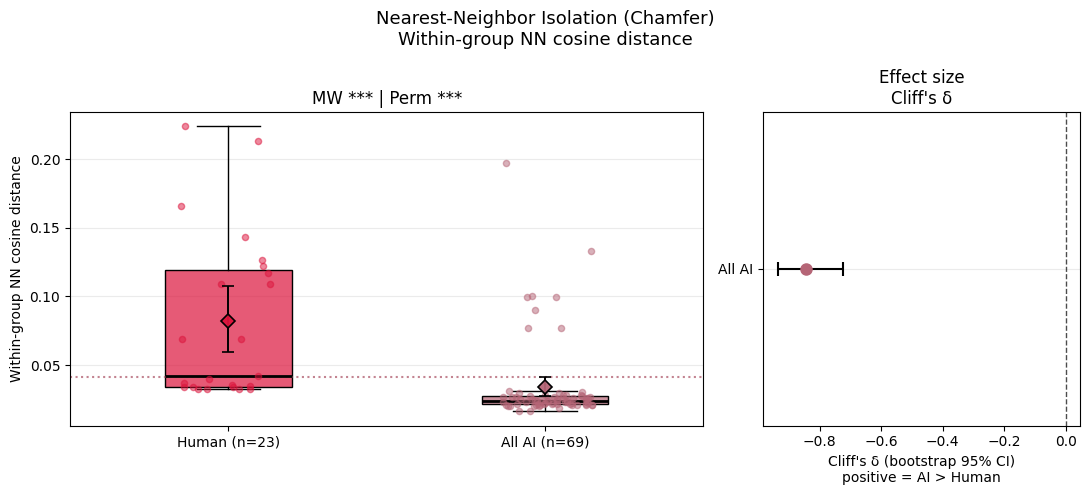

Saved nearest_neighbor_human_vs_allai.png


In [71]:
# Per-proposal NN distances (within-group)
human_nn   = per_proposal_nn(human_idx, D_pp)
ai_full_nn = per_proposal_nn(ai_idx, D_pp)

# Group-level Chamfer mean
human_chamfer   = group_chamfer(human_idx, D_pp)
ai_full_chamfer = group_chamfer(ai_idx, D_pp)
boot_cham_vals   = boot_metric_over_samples(group_chamfer, boot_ai_idx_samples, D_pp)
ai_boot_cham_mean = float(np.mean(boot_cham_vals))
ai_boot_cham_ci   = boot_ci(boot_cham_vals)

stat_nn, p_mw_nn = mannwhitneyu(ai_full_nn, human_nn, alternative='two-sided')
delta_nn = cliffs_delta(ai_full_nn, human_nn)
d_lo_nn, d_hi_nn = bootstrap_cliffs_delta_ci(ai_full_nn, human_nn)

rng_nn = np.random.default_rng(48)
all_nn = np.concatenate([human_nn, ai_full_nn])
obs_nn = np.mean(ai_full_nn) - np.mean(human_nn)
perm_nn = []
for _ in range(10000):
    p_arr = rng_nn.permutation(all_nn)
    perm_nn.append(np.mean(p_arr[len(human_nn):]) - np.mean(p_arr[:len(human_nn)]))
p_perm_nn = (np.sum(np.abs(perm_nn) >= abs(obs_nn)) + 1) / 10001

# NN source composition (global nearest neighbor excl. self)
nn_source_rows = []
for i in range(len(D_pp)):
    nn_j = int(np.argmin(D_pp_infdiag[i]))
    if i in human_idx:
        src_group = 'Human'
        src = 'other_human'
    else:
        src_group = 'AI'
        # find model of nn_j
        if nn_j in human_idx:
            src = 'human'
        elif nn_j in claude_idx:
            src = 'claude'
        elif nn_j in gemini_idx:
            src = 'gemini'
        elif nn_j in gpt_idx:
            src = 'gpt'
        else:
            src = 'unknown'
    nn_source_rows.append({'proposal_idx': i, 'group': src_group,
                            'nn_idx': nn_j, 'nn_source': src,
                            'nn_dist': float(D_pp_infdiag[i, nn_j])})
nn_source_df = pd.DataFrame(nn_source_rows)
nn_source_df.to_csv(TABLES_DIR_AI / 'nearest_neighbor_source_composition_human_vs_allai.csv',
                     index=False)

print(f'Human Chamfer: {human_chamfer:.4f}')
print(f'AI Full Chamfer: {ai_full_chamfer:.4f}')
print(f'AI Boot Chamfer: {ai_boot_cham_mean:.4f} [{ai_boot_cham_ci[0]:.4f}, {ai_boot_cham_ci[1]:.4f}]')
print(f"MW p={p_mw_nn:.4f} ({fmt_p(p_mw_nn)}), Perm p={p_perm_nn:.4f} ({fmt_p(p_perm_nn)})")
print('\nNN source composition (AI proposals):')
print(nn_source_df[nn_source_df['group'] == 'AI']['nn_source'].value_counts())

pd.DataFrame([{
    'human_chamfer': human_chamfer, 'ai_full_chamfer': ai_full_chamfer,
    'ai_boot_cham_mean': ai_boot_cham_mean,
    'ai_boot_cham_ci_lo': ai_boot_cham_ci[0], 'ai_boot_cham_ci_hi': ai_boot_cham_ci[1],
    'mw_p': p_mw_nn, 'perm_p': p_perm_nn,
    'cliffs_delta': delta_nn, 'cliffs_delta_ci_lo': d_lo_nn, 'cliffs_delta_ci_hi': d_hi_nn
}]).to_csv(TABLES_DIR_AI / 'diversity_chamfer_human_vs_allai.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Nearest-Neighbor Isolation (Chamfer)\nWithin-group NN cosine distance', fontsize=13)
draw_boxplot_with_jitter(axes[0],
    [human_nn, ai_full_nn],
    [f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})'],
    [HUMAN_COLOR, AI_COLOR])
axes[0].axhline(ai_boot_cham_mean, color=AI_COLOR, linewidth=1.5, linestyle=':', alpha=0.8)
axes[0].set_ylabel('Within-group NN cosine distance')
axes[0].set_title(f'MW {fmt_p(p_mw_nn)} | Perm {fmt_p(p_perm_nn)}')
draw_effect_size_panel(axes[1], delta_nn, d_lo_nn, d_hi_nn, p_val=p_perm_nn)
axes[1].set_title("Effect size\nCliff's δ")
plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'nearest_neighbor_human_vs_allai.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved nearest_neighbor_human_vs_allai.png')


## Analysis 2.4: UMAP Embedding Space Visualization

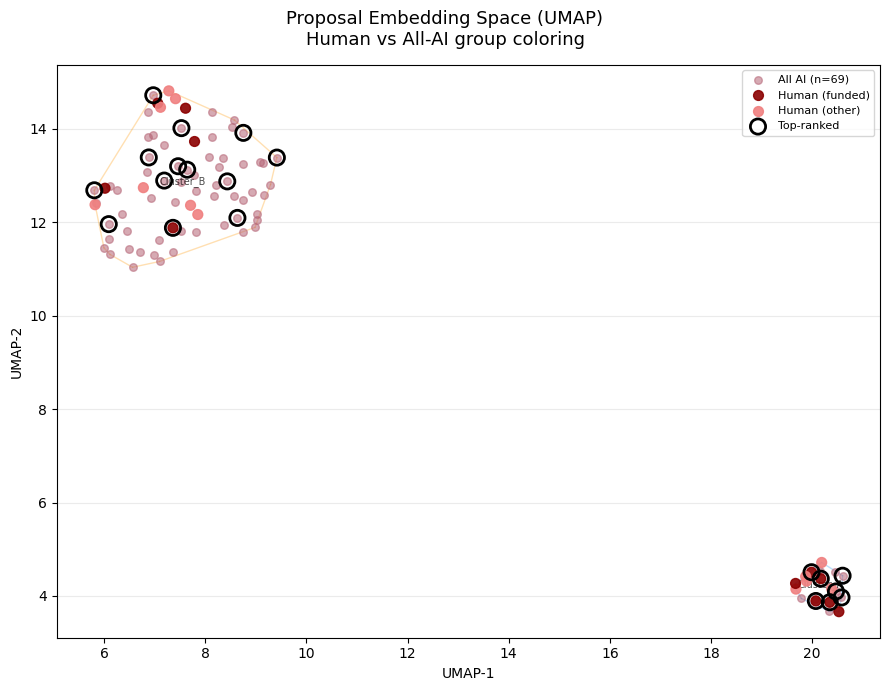

Saved embedding_space_umap_human_vs_allai.png


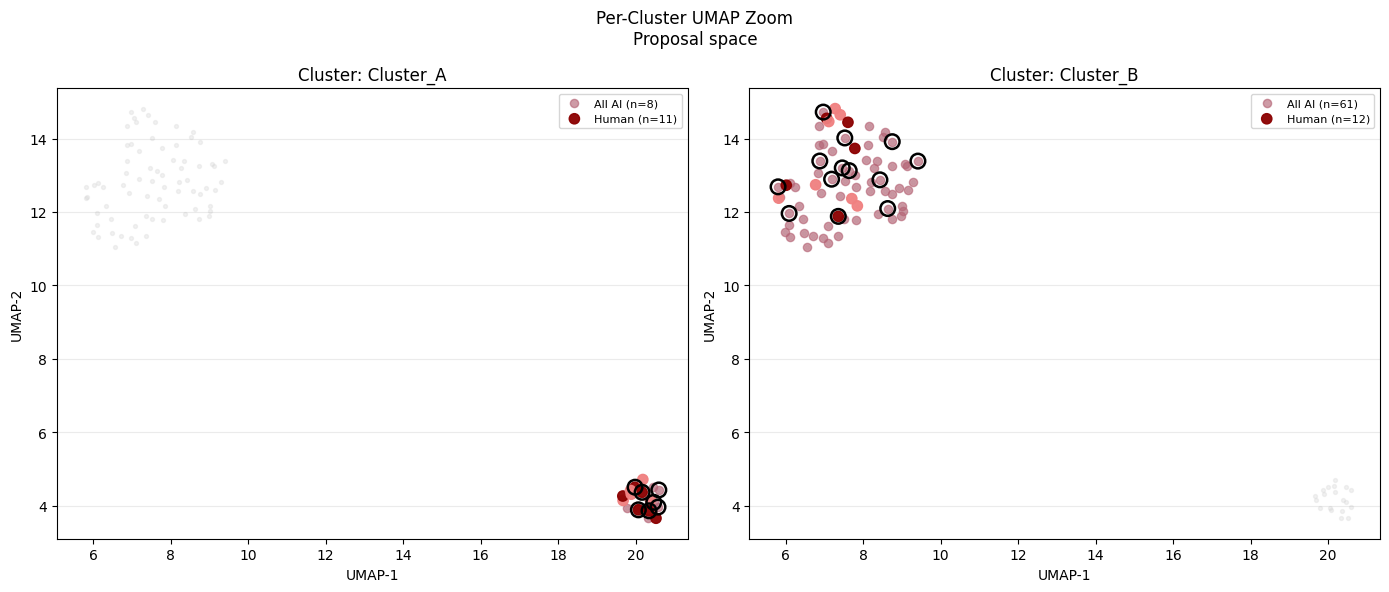

Saved embedding_space_umap_per_cluster_zoom_human_vs_allai.png


In [72]:
# Determine human point colors
if 'human_color_shade' in proposal_meta.columns:
    h_dot_colors = proposal_meta.loc[human_idx, 'human_color_shade'].values
elif 'funding' in proposal_meta.columns:
    h_dot_colors = np.where(
        proposal_meta.loc[human_idx, 'funding'].fillna('').str.lower() == 'funded',
        HUMAN_FUNDED_COLOR, HUMAN_NONFUNDED_COLOR)
else:
    h_dot_colors = np.full(len(human_idx), HUMAN_COLOR)

top_mask_arr = proposal_meta['is_top5_ranked'].fillna(False).astype(bool).values
top_idx_umap = proposal_meta.index[top_mask_arr].to_numpy()

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Proposal Embedding Space (UMAP)\nHuman vs All-AI group coloring', fontsize=13)

ax.scatter(X_umap2d[ai_idx, 0], X_umap2d[ai_idx, 1],
           c=AI_COLOR, s=30, alpha=0.55, label=f'All AI (n={len(ai_idx)})', zorder=3)
ax.scatter(X_umap2d[human_idx, 0], X_umap2d[human_idx, 1],
           c=h_dot_colors, s=50, alpha=0.9, zorder=4)

# Human legend patches
ax.scatter([], [], c=HUMAN_FUNDED_COLOR, s=50, label='Human (funded)', alpha=0.9)
ax.scatter([], [], c=HUMAN_NONFUNDED_COLOR, s=50, label='Human (other)', alpha=0.9)

# Top-ranked ring
if len(top_idx_umap) > 0:
    ax.scatter(X_umap2d[top_idx_umap, 0], X_umap2d[top_idx_umap, 1],
               s=120, facecolors='none', edgecolors='black', linewidths=2,
               zorder=6, label='Top-ranked')

# Ward cluster convex hull
try:
    from scipy.spatial import ConvexHull
    if topic_cluster_df is not None:
        tc_umap = topic_cluster_df.merge(
            proposal_meta[['title']], on='title', how='inner')
        tc_umap.index = tc_umap.index
        wc_col_u = 'ward_cluster_name' if 'ward_cluster_name' in tc_umap.columns else 'ward_cluster_display'
        if wc_col_u in tc_umap.columns:
            hull_colors = ['#2196F3', '#FF9800']
            for ci, cname in enumerate(sorted(tc_umap[wc_col_u].unique())):
                titles_c = tc_umap[tc_umap[wc_col_u] == cname]['title'].values
                idx_c = proposal_meta.index[proposal_meta['title'].isin(titles_c)].to_numpy()
                pts = X_umap2d[idx_c]
                if len(pts) >= 3:
                    try:
                        hull = ConvexHull(pts)
                        for simplex in hull.simplices:
                            ax.plot(pts[simplex, 0], pts[simplex, 1],
                                    color=hull_colors[ci % len(hull_colors)],
                                    alpha=0.3, linewidth=1)
                        ax.text(pts[:, 0].mean(), pts[:, 1].mean(),
                                str(cname)[:30], fontsize=7, ha='center', alpha=0.7)
                    except Exception:
                        pass
except ImportError:
    pass

ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(fontsize=8, loc='best')
ax.yaxis.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'embedding_space_umap_human_vs_allai.png',
            dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved embedding_space_umap_human_vs_allai.png')

# Per-cluster zoom (2-panel)
if topic_cluster_df is not None and wc_col_u in topic_cluster_df.columns:
    clusters_zoom = sorted(topic_cluster_df[wc_col_u].unique())
    fig2, axes2 = plt.subplots(1, len(clusters_zoom),
                                figsize=(7 * len(clusters_zoom), 6))
    if len(clusters_zoom) == 1:
        axes2 = [axes2]
    for ci2, (cname, axz) in enumerate(zip(clusters_zoom, axes2)):
        titles_c2 = topic_cluster_df[topic_cluster_df[wc_col_u] == cname]['title'].values
        idx_c2 = proposal_meta.index[proposal_meta['title'].isin(titles_c2)].to_numpy()
        h_c2 = np.intersect1d(idx_c2, human_idx)
        a_c2 = np.intersect1d(idx_c2, ai_idx)
        # Background
        axz.scatter(X_umap2d[:, 0], X_umap2d[:, 1], c='lightgray', s=8, alpha=0.3, zorder=1)
        axz.scatter(X_umap2d[a_c2, 0], X_umap2d[a_c2, 1],
                    c=AI_COLOR, s=35, alpha=0.65, zorder=3, label=f'All AI (n={len(a_c2)})')
        if len(h_c2) > 0:
            h_cs = proposal_meta.loc[h_c2, 'human_color_shade'].values if 'human_color_shade' in proposal_meta.columns else HUMAN_COLOR
            axz.scatter(X_umap2d[h_c2, 0], X_umap2d[h_c2, 1],
                        c=h_cs, s=55, alpha=0.95, zorder=4, label=f'Human (n={len(h_c2)})')
        top_in = np.intersect1d(top_idx_umap, idx_c2)
        if len(top_in) > 0:
            axz.scatter(X_umap2d[top_in, 0], X_umap2d[top_in, 1],
                        s=110, facecolors='none', edgecolors='black', linewidths=1.8, zorder=5)
        axz.set_xlabel('UMAP-1')
        axz.set_ylabel('UMAP-2')
        axz.set_title(f'Cluster: {str(cname)[:40]}')
        axz.legend(fontsize=8)
        axz.yaxis.grid(True, alpha=0.25)
    fig2.suptitle('Per-Cluster UMAP Zoom\nProposal space', fontsize=12)
    plt.tight_layout()
    fig2.savefig(FIGURES_DIR_AI / 'embedding_space_umap_per_cluster_zoom_human_vs_allai.png',
                 dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
    print('Saved embedding_space_umap_per_cluster_zoom_human_vs_allai.png')


## Analysis 2.5: Grid Entropy

Human entropy (norm): 0.4145
AI Full entropy:      0.3320 (n=69)
AI Boot entropy mean: 0.2667 [0.1105, 0.7586]
Perm p=0.4971 (p=0.497)


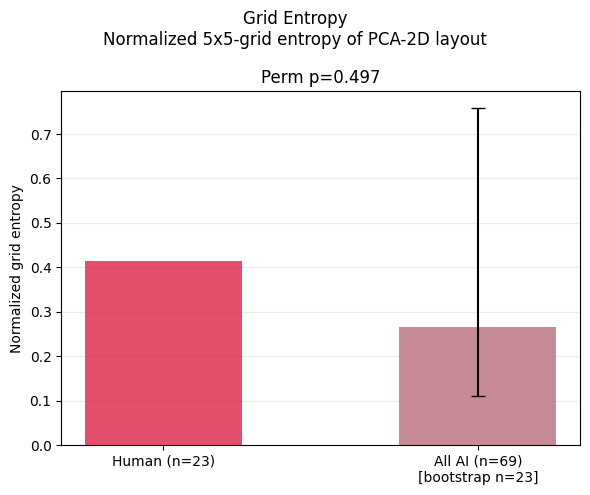

Saved diversity_entropy_human_vs_allai.png


In [73]:
human_ent   = group_grid_entropy(human_idx, X_pca2d)
ai_full_ent = group_grid_entropy(ai_idx, X_pca2d)

boot_ent_vals   = boot_metric_over_samples(group_grid_entropy, boot_ai_idx_samples, X_pca2d)
ai_boot_ent_mean = float(np.mean(boot_ent_vals))
ai_boot_ent_ci   = boot_ci(boot_ent_vals)

# Group-level permutation (permute binary assignment)
rng_ent = np.random.default_rng(49)
all_idx_ent = np.concatenate([human_idx, ai_idx])
obs_ent_diff = ai_full_ent - human_ent
perm_ent_diffs = []
for _ in range(5000):
    perm = rng_ent.permutation(all_idx_ent)
    h_p = perm[:len(human_idx)]
    a_p = perm[len(human_idx):]
    perm_ent_diffs.append(
        group_grid_entropy(a_p, X_pca2d) - group_grid_entropy(h_p, X_pca2d))
perm_ent_diffs = np.array(perm_ent_diffs)
p_perm_ent = (np.sum(np.abs(perm_ent_diffs) >= abs(obs_ent_diff)) + 1) / 5001

print(f'Human entropy (norm): {human_ent:.4f}')
print(f'AI Full entropy:      {ai_full_ent:.4f} (n=69)')
print(f'AI Boot entropy mean: {ai_boot_ent_mean:.4f} [{ai_boot_ent_ci[0]:.4f}, {ai_boot_ent_ci[1]:.4f}]')
print(f'Perm p={p_perm_ent:.4f} ({fmt_p(p_perm_ent)})')

pd.DataFrame([{
    'human_entropy': human_ent, 'ai_full_entropy': ai_full_ent,
    'ai_boot_ent_mean': ai_boot_ent_mean,
    'ai_boot_ent_ci_lo': ai_boot_ent_ci[0], 'ai_boot_ent_ci_hi': ai_boot_ent_ci[1],
    'obs_diff': obs_ent_diff, 'perm_p': p_perm_ent
}]).to_csv(TABLES_DIR_AI / 'diversity_entropy_human_vs_allai.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Grid Entropy\nNormalized 5x5-grid entropy of PCA-2D layout', fontsize=12)
bar_vals_e = [human_ent, ai_boot_ent_mean]
ax.bar([0, 1], bar_vals_e, color=[HUMAN_COLOR, AI_COLOR], alpha=0.75, width=0.5)
ax.errorbar(1, ai_boot_ent_mean,
            yerr=[[ai_boot_ent_mean - ai_boot_ent_ci[0]],
                  [ai_boot_ent_ci[1] - ai_boot_ent_mean]],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})\n[bootstrap n=23]'])
ax.set_ylabel('Normalized grid entropy')
ax.set_title(f'Perm {fmt_p(p_perm_ent)}')
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(FIGURES_DIR_AI / 'diversity_entropy_human_vs_allai.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved diversity_entropy_human_vs_allai.png')


## Part II Diversity Summary Table

In [74]:
div_summary_rows = [
    {'metric': 'Mean Pairwise Distance',
     'human_val': human_mpd, 'ai_full_val': ai_full_mpd,
     'ai_boot_mean': ai_boot_mpd, 'ai_boot_ci_lo': ai_boot_mpd_ci[0], 'ai_boot_ci_hi': ai_boot_mpd_ci[1],
     'mw_p': p_mw, 'perm_p': p_perm_pp, 'cliffs_delta': delta},
    {'metric': 'LOO Centroid Distance',
     'human_val': human_loo_mean, 'ai_full_val': ai_full_loo_mean,
     'ai_boot_mean': ai_boot_loo_mean, 'ai_boot_ci_lo': ai_boot_loo_ci[0], 'ai_boot_ci_hi': ai_boot_loo_ci[1],
     'mw_p': p_mw_loo, 'perm_p': p_perm_loo, 'cliffs_delta': delta_loo},
    {'metric': 'Global Centroid Distance',
     'human_val': float(np.mean(human_gc)), 'ai_full_val': float(np.mean(ai_full_gc)),
     'ai_boot_mean': ai_boot_gc_mean, 'ai_boot_ci_lo': ai_boot_gc_ci[0], 'ai_boot_ci_hi': ai_boot_gc_ci[1],
     'mw_p': p_mw_gc, 'perm_p': p_perm_gc, 'cliffs_delta': delta_gc},
    {'metric': 'MST Mean Edge Weight',
     'human_val': human_mst, 'ai_full_val': ai_full_mst,
     'ai_boot_mean': ai_boot_mst_mean, 'ai_boot_ci_lo': ai_boot_mst_ci[0], 'ai_boot_ci_hi': ai_boot_mst_ci[1],
     'mw_p': np.nan, 'perm_p': p_perm_mst, 'cliffs_delta': np.nan},
    {'metric': 'Sparseness (Medoid)',
     'human_val': human_spar, 'ai_full_val': ai_full_spar,
     'ai_boot_mean': ai_boot_spar_mean, 'ai_boot_ci_lo': ai_boot_spar_ci[0], 'ai_boot_ci_hi': ai_boot_spar_ci[1],
     'mw_p': p_mw_spar, 'perm_p': p_perm_spar, 'cliffs_delta': delta_spar},
    {'metric': 'Chamfer (NN Distance)',
     'human_val': human_chamfer, 'ai_full_val': ai_full_chamfer,
     'ai_boot_mean': ai_boot_cham_mean, 'ai_boot_ci_lo': ai_boot_cham_ci[0], 'ai_boot_ci_hi': ai_boot_cham_ci[1],
     'mw_p': p_mw_nn, 'perm_p': p_perm_nn, 'cliffs_delta': delta_nn},
    {'metric': 'Grid Entropy (norm)',
     'human_val': human_ent, 'ai_full_val': ai_full_ent,
     'ai_boot_mean': ai_boot_ent_mean, 'ai_boot_ci_lo': ai_boot_ent_ci[0], 'ai_boot_ci_hi': ai_boot_ent_ci[1],
     'mw_p': np.nan, 'perm_p': p_perm_ent, 'cliffs_delta': np.nan},
]
div_summary_df = pd.DataFrame(div_summary_rows)
div_summary_df['mw_sig'] = div_summary_df['mw_p'].apply(fmt_p)
div_summary_df['perm_sig'] = div_summary_df['perm_p'].apply(fmt_p)
div_summary_df.to_csv(TABLES_DIR_AI / 'diversity_summary_human_vs_allai.csv', index=False)
print('Diversity Summary:')
print(div_summary_df[['metric', 'human_val', 'ai_boot_mean', 'perm_p', 'perm_sig', 'cliffs_delta']].to_string())


Diversity Summary:
                     metric  human_val  ai_boot_mean    perm_p perm_sig  cliffs_delta
0    Mean Pairwise Distance   0.442918      0.182360  0.000100      ***     -0.768116
1     LOO Centroid Distance   0.266497      0.099142  0.000400      ***     -0.768116
2  Global Centroid Distance   0.292597      0.098908  0.000100      ***     -0.724008
3      MST Mean Edge Weight   0.112587      0.063754  0.000200      ***           NaN
4       Sparseness (Medoid)   0.372057      0.109769  0.000200      ***     -0.742281
5     Chamfer (NN Distance)   0.082153      0.041500  0.000100      ***     -0.843730
6       Grid Entropy (norm)   0.414456      0.266722  0.497101  p=0.497           NaN


# PART III: NOVELTY

All novelty metrics are per-proposal. Tested with Mann-Whitney U. No subsampling needed.
All cached CSVs were loaded at the top.

## Analysis 3.2.5: Element Novelty Percentiles

In [75]:
if novelty_element_df is None:
    print('WARNING: novelty_element_df not loaded — skipping Analysis 3.2.5')
else:
    el_cols = [c for c in novelty_element_df.columns if c.startswith('element_novel')]
    human_el = novelty_element_df[novelty_element_df['group_binary'] == 'Human']
    ai_el    = novelty_element_df[novelty_element_df['group_binary'] == 'AI']
    el_rows = []
    for col in el_cols:
        h_v = human_el[col].values
        a_v = ai_el[col].values
        stat_el, p_el = mannwhitneyu(a_v, h_v, alternative='two-sided')
        d_el = cliffs_delta(a_v, h_v)
        d_lo_el, d_hi_el = bootstrap_cliffs_delta_ci(a_v, h_v)
        el_rows.append({
            'metric': col,
            'human_mean': float(np.mean(h_v)), 'ai_mean': float(np.mean(a_v)),
            'mw_p': p_el, 'cliffs_delta': d_el,
            'cliffs_delta_ci_lo': d_lo_el, 'cliffs_delta_ci_hi': d_hi_el
        })
    el_df = pd.DataFrame(el_rows)
    if len(el_df) > 0:
        _, el_df['p_holm'], _, _ = multipletests(el_df['mw_p'], method='holm')
    el_df['mw_sig'] = el_df['mw_p'].apply(fmt_p)
    el_df.to_csv(TABLES_DIR_AI / 'novelty_element_percentiles_human_vs_allai.csv', index=False)
    print(el_df[['metric', 'human_mean', 'ai_mean', 'mw_p', 'p_holm', 'cliffs_delta']].to_string())


             metric  human_mean   ai_mean          mw_p        p_holm  cliffs_delta
0   element_novel_0    0.122032  0.064220  3.502670e-09  3.502670e-09     -0.826087
1   element_novel_1    0.196525  0.115042  3.685548e-10  7.371095e-10     -0.876497
2   element_novel_5    0.228571  0.139621  9.532482e-11  2.859745e-10     -0.905482
3  element_novel_10    0.247778  0.154191  7.065028e-11  2.826011e-10     -0.911783


## Step 3: Mean kNN Novelty Scores and Local Density

In [76]:
knn_rows = []
if novelty_knn_df is not None:
    knn_cols = [c for c in novelty_knn_df.columns if c.startswith('mean_knn')]
    human_knn = novelty_knn_df[novelty_knn_df['group_binary'] == 'Human']
    ai_knn    = novelty_knn_df[novelty_knn_df['group_binary'] == 'AI']
    for col in knn_cols:
        h_v = human_knn[col].values
        a_v = ai_knn[col].values
        stat_k, p_k = mannwhitneyu(a_v, h_v, alternative='two-sided')
        d_k = cliffs_delta(a_v, h_v)
        d_lo_k, d_hi_k = bootstrap_cliffs_delta_ci(a_v, h_v)
        knn_rows.append({
            'metric': col, 'human_mean': float(np.mean(h_v)), 'ai_mean': float(np.mean(a_v)),
            'mw_p': p_k, 'cliffs_delta': d_k,
            'cliffs_delta_ci_lo': d_lo_k, 'cliffs_delta_ci_hi': d_hi_k
        })

if novelty_norm_df is not None:
    norm_cols = [c for c in ['novelty_ratio', 'novelty_z'] if c in novelty_norm_df.columns]
    human_norm = novelty_norm_df[novelty_norm_df['group_binary'] == 'Human']
    ai_norm    = novelty_norm_df[novelty_norm_df['group_binary'] == 'AI']
    for col in norm_cols:
        h_v = human_norm[col].values
        a_v = ai_norm[col].values
        stat_n, p_n = mannwhitneyu(a_v, h_v, alternative='two-sided')
        d_n = cliffs_delta(a_v, h_v)
        d_lo_n, d_hi_n = bootstrap_cliffs_delta_ci(a_v, h_v)
        knn_rows.append({
            'metric': col, 'human_mean': float(np.mean(h_v)), 'ai_mean': float(np.mean(a_v)),
            'mw_p': p_n, 'cliffs_delta': d_n,
            'cliffs_delta_ci_lo': d_lo_n, 'cliffs_delta_ci_hi': d_hi_n
        })

if knn_rows:
    knn_df_out = pd.DataFrame(knn_rows)
    _, knn_df_out['p_holm'], _, _ = multipletests(knn_df_out['mw_p'], method='holm')
    knn_df_out['mw_sig'] = knn_df_out['mw_p'].apply(fmt_p)
    knn_df_out.to_csv(TABLES_DIR_AI / 'novelty_knn_density_human_vs_allai.csv', index=False)
    print(knn_df_out[['metric', 'human_mean', 'ai_mean', 'mw_p', 'p_holm', 'cliffs_delta']].to_string())
else:
    print('WARNING: No novelty kNN/density data available')
    knn_df_out = None


          metric  human_mean   ai_mean          mw_p        p_holm  cliffs_delta
0     mean_knn_5    0.131608  0.070624  4.125897e-09  2.475538e-08     -0.822306
1    mean_knn_10    0.137393  0.075471  7.886723e-09  3.943361e-08     -0.807183
2    mean_knn_20    0.144033  0.080283  1.029615e-08  3.943361e-08     -0.800882
3    mean_knn_50    0.154228  0.086887  8.319957e-09  3.943361e-08     -0.805923
4  novelty_ratio    1.223357  1.166673  3.483652e-01  3.483652e-01     -0.131695
5      novelty_z    1.043098  0.453464  1.030087e-03  2.060175e-03     -0.459357


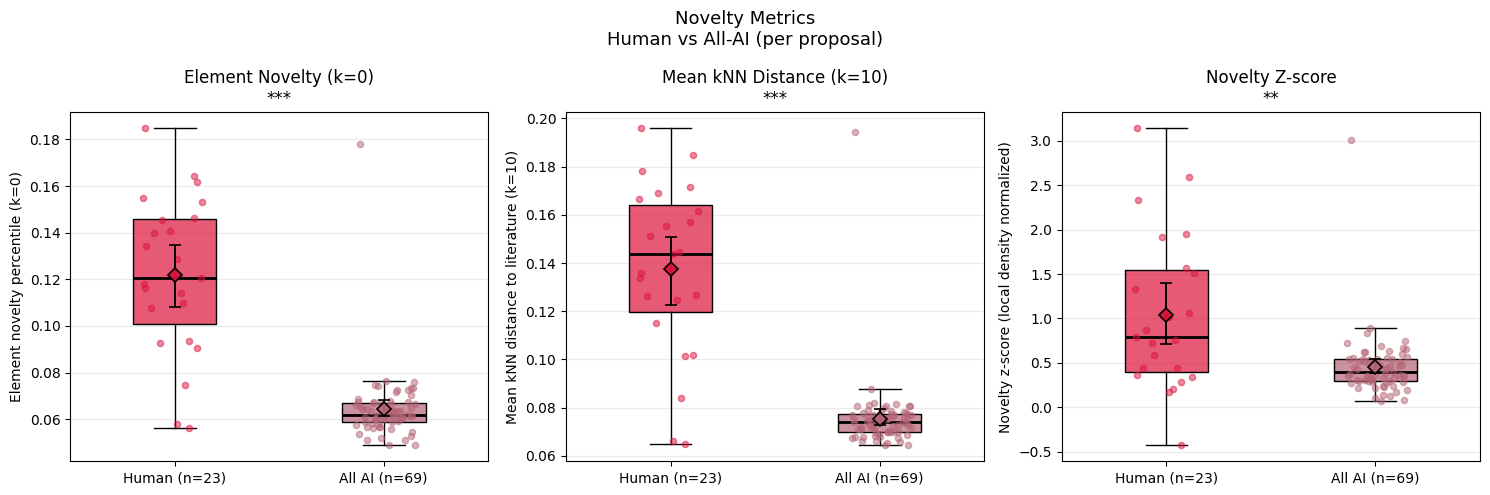

Saved novelty_human_vs_allai.png


In [77]:
# Novelty figure: 3-panel boxplots if data available
_have_el   = novelty_element_df is not None and 'element_novel_0' in novelty_element_df.columns
_have_knn  = novelty_knn_df is not None and 'mean_knn_10' in novelty_knn_df.columns
_have_norm = novelty_norm_df is not None and 'novelty_z' in novelty_norm_df.columns

n_panels = sum([_have_el, _have_knn, _have_norm])
if n_panels == 0:
    print('WARNING: No novelty data for figure')
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]
    fig.suptitle('Novelty Metrics\nHuman vs All-AI (per proposal)', fontsize=13)
    panel_i = 0

    if _have_el:
        col = 'element_novel_0'
        h_v = novelty_element_df[novelty_element_df['group_binary'] == 'Human'][col].values
        a_v = novelty_element_df[novelty_element_df['group_binary'] == 'AI'][col].values
        draw_boxplot_with_jitter(axes[panel_i], [h_v, a_v],
            [f'Human (n={len(h_v)})', f'All AI (n={len(a_v)})'],
            [HUMAN_COLOR, AI_COLOR])
        _, p_tmp = mannwhitneyu(a_v, h_v, alternative='two-sided')
        axes[panel_i].set_ylabel('Element novelty percentile (k=0)')
        axes[panel_i].set_title(f'Element Novelty (k=0)\n{fmt_p(p_tmp)}')
        panel_i += 1

    if _have_knn:
        col = 'mean_knn_10'
        h_v = novelty_knn_df[novelty_knn_df['group_binary'] == 'Human'][col].values
        a_v = novelty_knn_df[novelty_knn_df['group_binary'] == 'AI'][col].values
        draw_boxplot_with_jitter(axes[panel_i], [h_v, a_v],
            [f'Human (n={len(h_v)})', f'All AI (n={len(a_v)})'],
            [HUMAN_COLOR, AI_COLOR])
        _, p_tmp = mannwhitneyu(a_v, h_v, alternative='two-sided')
        axes[panel_i].set_ylabel('Mean kNN distance to literature (k=10)')
        axes[panel_i].set_title(f'Mean kNN Distance (k=10)\n{fmt_p(p_tmp)}')
        panel_i += 1

    if _have_norm:
        col = 'novelty_z'
        h_v = novelty_norm_df[novelty_norm_df['group_binary'] == 'Human'][col].values
        a_v = novelty_norm_df[novelty_norm_df['group_binary'] == 'AI'][col].values
        draw_boxplot_with_jitter(axes[panel_i], [h_v, a_v],
            [f'Human (n={len(h_v)})', f'All AI (n={len(a_v)})'],
            [HUMAN_COLOR, AI_COLOR])
        _, p_tmp = mannwhitneyu(a_v, h_v, alternative='two-sided')
        axes[panel_i].set_ylabel('Novelty z-score (local density normalized)')
        axes[panel_i].set_title(f'Novelty Z-score\n{fmt_p(p_tmp)}')
        panel_i += 1

    plt.tight_layout()
    fig.savefig(FIGURES_DIR_AI / 'novelty_human_vs_allai.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved novelty_human_vs_allai.png')


## Step 7B: Literature-Space Outliers

In [78]:
outlier_cols = []
if master_df is not None:
    out_candidates = ['is_lit_outlier_mean10', 'is_lit_outlier_element0', 'is_lit_outlier_z']
    for col in out_candidates:
        if col in master_df.columns:
            outlier_cols.append(col)

if not outlier_cols:
    # Try loading individual CSVs
    _out_paths = [
        TABLES_DIR / 'literature_space_outliers_mean_knn_k10.csv',
        TABLES_DIR / 'literature_space_outliers_z.csv'
    ]
    for p in _out_paths:
        if p.exists():
            _odf = pd.read_csv(p)
            print(f'Loaded: {p.name}, columns: {_odf.columns.tolist()}')
    if not outlier_cols:
        print('WARNING: No literature-space outlier data found — skipping Step 7B')

if outlier_cols and master_df is not None:
    out_rows = []
    for col in outlier_cols:
        h_mask = master_df.index.isin(human_idx) if 'proposal_uid' not in master_df.columns else \
            master_df['group_binary'] == 'Human'
        a_mask = master_df.index.isin(ai_idx) if 'proposal_uid' not in master_df.columns else \
            master_df['group_binary'] == 'AI'
        h_out = master_df[h_mask][col].fillna(0).astype(int)
        a_out = master_df[a_mask][col].fillna(0).astype(int)
        ct = np.array([
            [h_out.sum(), (1 - h_out).sum()],
            [a_out.sum(), (1 - a_out).sum()]
        ])
        _, p_f = fisher_exact(ct)
        out_rows.append({
            'metric': col,
            'human_outlier_n': int(h_out.sum()),
            'ai_outlier_n': int(a_out.sum()),
            'human_outlier_frac': float(h_out.mean()),
            'ai_outlier_frac': float(a_out.mean()),
            'fisher_p': p_f
        })
    out_df = pd.DataFrame(out_rows)
    if len(out_df) > 0:
        _, out_df['p_holm'], _, _ = multipletests(out_df['fisher_p'], method='holm')
    out_df.to_csv(TABLES_DIR_AI / 'literature_space_outliers_human_vs_allai.csv', index=False)
    print(out_df.to_string())


                    metric  human_outlier_n  ai_outlier_n  human_outlier_frac  ai_outlier_frac  fisher_p    p_holm
0    is_lit_outlier_mean10                9             1            0.391304         0.014493  0.000008  0.000024
1  is_lit_outlier_element0                9             1            0.391304         0.014493  0.000008  0.000024
2         is_lit_outlier_z                9             1            0.391304         0.014493  0.000008  0.000024


## Analysis 3.5: Literature-Anchored UMAP

Loaded precomputed lit UMAP coords: (92, 2)


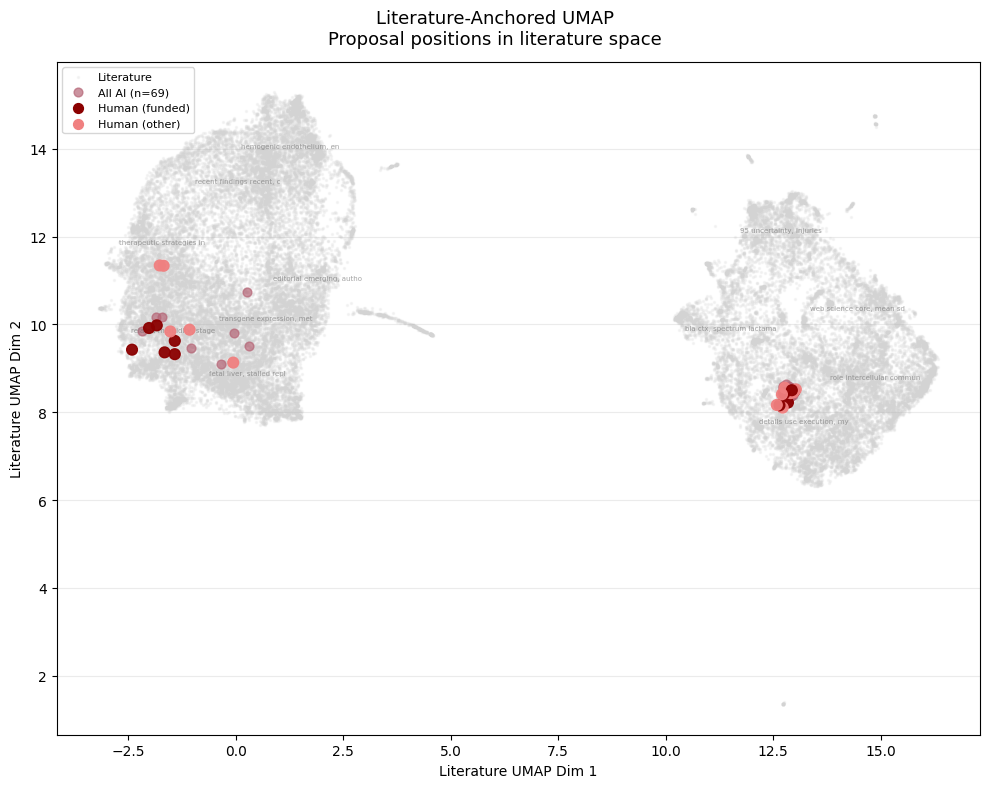

Saved literature_umap_human_vs_allai.png


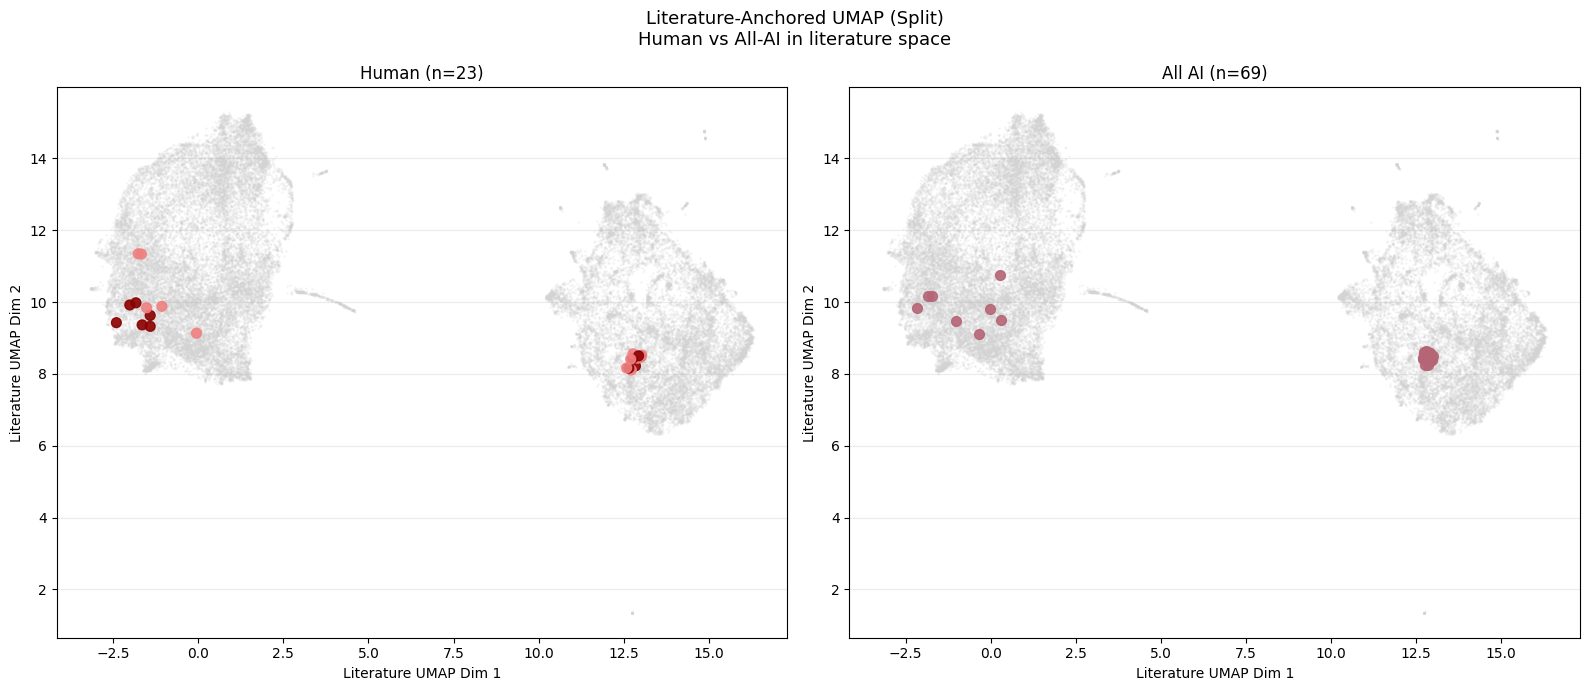

Saved literature_umap_human_vs_allai_split.png


In [79]:
# Project proposals into literature space if reducer available
_proj_path = (PROJECT_ROOT / 'data' / 'prepared' / condition /
               'proposal_full_coords_in_lit_umap.npy')
if _proj_path.exists():
    prop_lit_coords = np.load(str(_proj_path))
    print(f'Loaded precomputed lit UMAP coords: {prop_lit_coords.shape}')
elif lit_umap_reducer is not None:
    try:
        prop_lit_coords = lit_umap_reducer.transform(X_prop)
        print(f'Projected proposals into lit UMAP: {prop_lit_coords.shape}')
    except Exception as e:
        print(f'WARNING: Could not project into lit UMAP: {e}')
        prop_lit_coords = None
else:
    prop_lit_coords = None
    print('WARNING: No literature UMAP coordinates available — skipping Analysis 3.5')

if prop_lit_coords is not None and lit_umap2d is not None:
    # Get human funding colors
    if 'human_color_shade' in proposal_meta.columns:
        h_lit_colors = proposal_meta.loc[human_idx, 'human_color_shade'].values
    else:
        h_lit_colors = np.full(len(human_idx), HUMAN_COLOR)

    # Full view
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.suptitle('Literature-Anchored UMAP\nProposal positions in literature space', fontsize=13)
    ax.scatter(lit_umap2d[:, 0], lit_umap2d[:, 1],
               c='lightgray', s=2, alpha=0.2, zorder=1, label='Literature')
    ax.scatter(prop_lit_coords[ai_idx, 0], prop_lit_coords[ai_idx, 1],
               c=AI_COLOR, s=40, alpha=0.7, zorder=3, label=f'All AI (n={len(ai_idx)})')
    ax.scatter(prop_lit_coords[human_idx, 0], prop_lit_coords[human_idx, 1],
               c=h_lit_colors, s=60, alpha=0.95, zorder=4)
    ax.scatter([], [], c=HUMAN_FUNDED_COLOR, s=50, label='Human (funded)')
    ax.scatter([], [], c=HUMAN_NONFUNDED_COLOR, s=50, label='Human (other)')
    # BERTopic region labels
    if lit_bertopic_df is not None and 'bertopic_label' in lit_bertopic_df.columns:
        from collections import defaultdict
        region_coords = defaultdict(list)
        for _, row_lb in lit_bertopic_df.iterrows():
            idx_lb = int(row_lb['article_idx']) if 'article_idx' in lit_bertopic_df.columns else None
            if idx_lb is not None and idx_lb < len(lit_umap2d):
                region_coords[str(row_lb['bertopic_label'])[:25]].append(
                    lit_umap2d[idx_lb])
        for lbl, pts in list(region_coords.items())[:15]:
            pts_arr = np.array(pts)
            ax.text(pts_arr[:, 0].mean(), pts_arr[:, 1].mean(), lbl,
                    fontsize=5, ha='center', alpha=0.6, color='dimgray')
    ax.set_xlabel('Literature UMAP Dim 1')
    ax.set_ylabel('Literature UMAP Dim 2')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.25)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR_AI / 'literature_umap_human_vs_allai.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved literature_umap_human_vs_allai.png')

    # Split view
    fig2, (ax_h, ax_a) = plt.subplots(1, 2, figsize=(16, 7))
    fig2.suptitle('Literature-Anchored UMAP (Split)\nHuman vs All-AI in literature space', fontsize=13)
    for ax_s, group_name, idx_s, cols_s in [
        (ax_h, 'Human', human_idx, h_lit_colors),
        (ax_a, 'All AI', ai_idx, AI_COLOR)
    ]:
        ax_s.scatter(lit_umap2d[:, 0], lit_umap2d[:, 1],
                     c='lightgray', s=1, alpha=0.15, zorder=1)
        ax_s.scatter(prop_lit_coords[idx_s, 0], prop_lit_coords[idx_s, 1],
                     c=cols_s, s=50, alpha=0.9, zorder=3)
        ax_s.set_title(f'{group_name} (n={len(idx_s)})')
        ax_s.set_xlabel('Literature UMAP Dim 1')
        ax_s.set_ylabel('Literature UMAP Dim 2')
        ax_s.yaxis.grid(True, alpha=0.25)
    plt.tight_layout()
    fig2.savefig(FIGURES_DIR_AI / 'literature_umap_human_vs_allai_split.png',
                 dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
    print('Saved literature_umap_human_vs_allai_split.png')


## Analysis 3.6: BERTopic Region Coverage

Human BERTopic breadth: 5 distinct regions
AI Full breadth: 2 (n=69)
AI Boot breadth: 1.34 [1.00, 2.00]
                   metric  human_mean   ai_mean      mw_p  cliffs_delta  cliffs_delta_ci_lo  cliffs_delta_ci_hi    p_holm  breadth_human  breadth_ai_full  breadth_ai_boot_mean
0       max_region_weight    0.800000  0.957971  0.000014      0.563327            0.314319            0.778828  0.000028              5                2                 1.337
1          region_entropy    0.495996  0.123566  0.000009     -0.574669           -0.790186           -0.322448  0.000028              5                2                 1.337
2  effective_region_count    1.785358  1.157942  0.000009     -0.574669           -0.790186           -0.322448  0.000028              5                2                 1.337


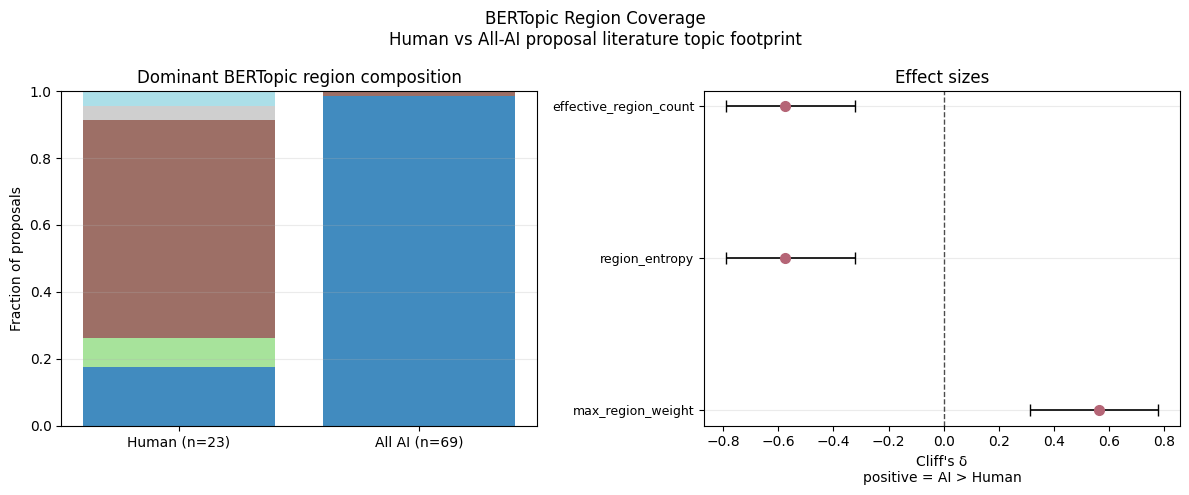

Saved bertopic_region_coverage_human_vs_allai.png


In [80]:
if bertopic_proposal_df is None:
    print('WARNING: bertopic_proposal_df not loaded — skipping Analysis 3.6')
else:
    bert_human = bertopic_proposal_df[bertopic_proposal_df['group_binary'] == 'Human']
    bert_ai    = bertopic_proposal_df[bertopic_proposal_df['group_binary'] == 'AI']

    bert_rows = []
    per_proposal_bert_cols = ['max_region_weight', 'region_entropy', 'effective_region_count']
    for col in per_proposal_bert_cols:
        if col not in bertopic_proposal_df.columns:
            continue
        h_v = bert_human[col].dropna().values
        a_v = bert_ai[col].dropna().values
        stat_b, p_b = mannwhitneyu(a_v, h_v, alternative='two-sided')
        d_b = cliffs_delta(a_v, h_v)
        d_lo_b, d_hi_b = bootstrap_cliffs_delta_ci(a_v, h_v)
        bert_rows.append({
            'metric': col, 'human_mean': float(np.mean(h_v)), 'ai_mean': float(np.mean(a_v)),
            'mw_p': p_b, 'cliffs_delta': d_b,
            'cliffs_delta_ci_lo': d_lo_b, 'cliffs_delta_ci_hi': d_hi_b
        })

    # Group-level breadth (N-sensitive): n distinct dominant regions
    if 'dominant_region' in bertopic_proposal_df.columns:
        human_breadth = int(bert_human['dominant_region'].nunique())

        def _breadth_fn(s_idx, bdf, meta):
            titles_s = meta.loc[s_idx, 'title'].values
            subset = bdf[bdf['title'].isin(titles_s)]
            return float(subset['dominant_region'].nunique())

        boot_breadth_vals = np.array([
            _breadth_fn(s, bertopic_proposal_df, proposal_meta)
            for s in boot_ai_idx_samples
        ])
        ai_full_breadth = int(bert_ai['dominant_region'].nunique())
        ai_boot_breadth_mean = float(np.mean(boot_breadth_vals))
        ai_boot_breadth_ci   = boot_ci(boot_breadth_vals)
        print(f'Human BERTopic breadth: {human_breadth} distinct regions')
        print(f'AI Full breadth: {ai_full_breadth} (n=69)')
        print(f'AI Boot breadth: {ai_boot_breadth_mean:.2f} [{ai_boot_breadth_ci[0]:.2f}, {ai_boot_breadth_ci[1]:.2f}]')
    else:
        human_breadth = ai_full_breadth = ai_boot_breadth_mean = np.nan
        ai_boot_breadth_ci = (np.nan, np.nan)
        boot_breadth_vals = np.array([])

    bert_df_out = pd.DataFrame(bert_rows)
    if len(bert_df_out) > 0:
        _, bert_df_out['p_holm'], _, _ = multipletests(bert_df_out['mw_p'], method='holm')
    bert_df_out['breadth_human'] = human_breadth
    bert_df_out['breadth_ai_full'] = ai_full_breadth
    bert_df_out['breadth_ai_boot_mean'] = ai_boot_breadth_mean
    bert_df_out.to_csv(TABLES_DIR_AI / 'bertopic_region_coverage_human_vs_allai.csv', index=False)
    print(bert_df_out.to_string())

    # Figure: stacked bar + forest plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('BERTopic Region Coverage\nHuman vs All-AI proposal literature topic footprint',
                 fontsize=12)

    # Stacked bar by dominant region
    ax_bar = axes[0]
    if 'dominant_region_label' in bertopic_proposal_df.columns:
        reg_col = 'dominant_region_label'
    elif 'dominant_region' in bertopic_proposal_df.columns:
        reg_col = 'dominant_region'
    else:
        reg_col = None
    if reg_col:
        all_regs = sorted(bertopic_proposal_df[reg_col].dropna().unique())
        h_fracs = [(bert_human[reg_col] == r).mean() for r in all_regs]
        a_fracs = [(bert_ai[reg_col] == r).mean() for r in all_regs]
        region_pal = plt.cm.tab20(np.linspace(0, 1, len(all_regs)))
        bottoms_h, bottoms_a = 0.0, 0.0
        for rcc, hf, af, rc in zip(all_regs, h_fracs, a_fracs, region_pal):
            ax_bar.bar([0], [hf], bottom=[bottoms_h], color=rc, alpha=0.85,
                       label=str(rcc)[:20] if hf > 0.03 else '')
            ax_bar.bar([1], [af], bottom=[bottoms_a], color=rc, alpha=0.85)
            bottoms_h += hf; bottoms_a += af
        ax_bar.set_xticks([0, 1])
        ax_bar.set_xticklabels([f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})'])
        ax_bar.set_ylabel('Fraction of proposals')
        ax_bar.set_title('Dominant BERTopic region composition')
        ax_bar.yaxis.grid(True, alpha=0.25)

    # Forest plot
    ax_f = axes[1]
    ax_f.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    if len(bert_df_out) > 0:
        ys = list(range(len(bert_df_out)))
        for yi, row_b in bert_df_out.iterrows():
            d_b = row_b['cliffs_delta']
            lo_b = row_b['cliffs_delta_ci_lo']
            hi_b = row_b['cliffs_delta_ci_hi']
            ax_f.errorbar(d_b, yi, xerr=[[d_b - lo_b], [hi_b - d_b]],
                          fmt='o', color=AI_COLOR, markersize=7,
                          ecolor='black', elinewidth=1.2, capsize=4)
        ax_f.set_yticks(list(range(len(bert_df_out))))
        ax_f.set_yticklabels(bert_df_out['metric'].values, fontsize=9)
        ax_f.set_xlabel("Cliff's δ\npositive = AI > Human")
        ax_f.set_title('Effect sizes')
        ax_f.yaxis.grid(True, alpha=0.25)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR_AI / 'bertopic_region_coverage_human_vs_allai.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved bertopic_region_coverage_human_vs_allai.png')


## Analysis 3.7: MeSH Term Coverage

Built MeSH sets from 20 nearest lit neighbors. Mean count: 81.2
Human per-proposal MeSH: mean=108.0
AI per-proposal MeSH:    mean=72.2
MW p=0.0000 (***), Cliff's d=-0.781
Human union MeSH: 1248
AI Boot union: 377.8 [304.0, 462.0]


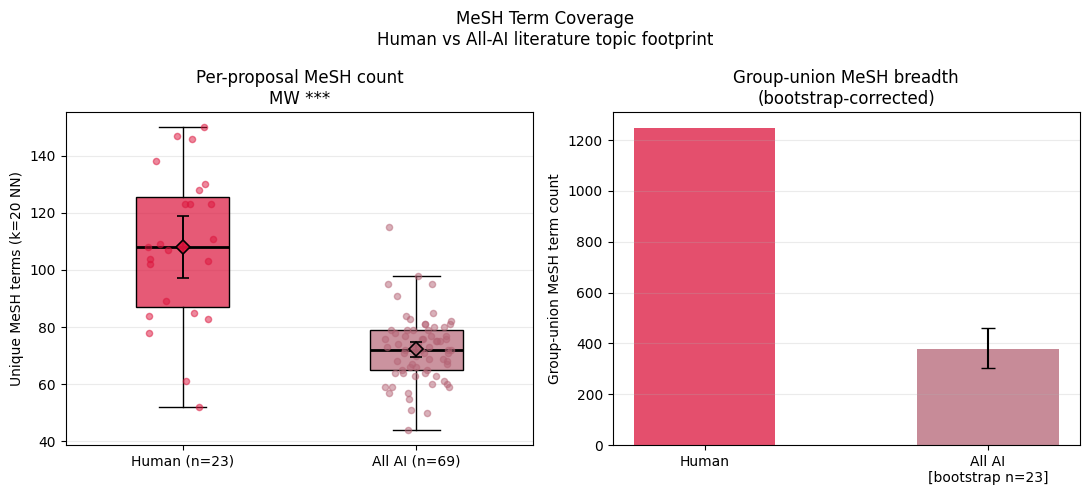

Saved mesh_coverage_human_vs_allai.png


In [81]:
# Build per-proposal MeSH sets from nearest literature neighbors
if D_pl_sorted_idx is not None and articles:
    k_mesh = 20
    mesh_per_prop = []
    for i in range(len(D_pp)):
        nn_arts = D_pl_sorted_idx[i, :k_mesh]
        mesh_set = set()
        for art_idx in nn_arts:
            if art_idx < len(articles):
                mt = articles[art_idx].get('mesh_terms', [])
                if mt:
                    mesh_set.update(mt)
        mesh_per_prop.append(mesh_set)
    mesh_counts = np.array([len(s) for s in mesh_per_prop])
    print(f'Built MeSH sets from {k_mesh} nearest lit neighbors. Mean count: {np.mean(mesh_counts):.1f}')
elif mesh_proposal_df is not None:
    # Fallback: use precomputed per-proposal counts
    mesh_counts = np.zeros(len(D_pp))
    for _, row_m in mesh_proposal_df.iterrows():
        # match by proposal_uid or title
        if 'proposal_uid' in mesh_proposal_df.columns:
            match = proposal_meta[proposal_meta['proposal_uid'] == row_m['proposal_uid']]
        else:
            match = proposal_meta[proposal_meta['title'] == row_m['title']]
        if len(match) > 0:
            mesh_counts[match.index[0]] = row_m.get('unique_mesh_count', 0)
    mesh_per_prop = None
    print('Using precomputed MeSH counts from mesh_proposal_df')
else:
    mesh_per_prop = None
    mesh_counts = None
    print('WARNING: No MeSH data available — skipping Analysis 3.7')

if mesh_counts is not None:
    human_mesh_counts = mesh_counts[human_idx]
    ai_full_mesh_counts = mesh_counts[ai_idx]

    stat_mesh, p_mw_mesh = mannwhitneyu(ai_full_mesh_counts, human_mesh_counts,
                                         alternative='two-sided')
    delta_mesh = cliffs_delta(ai_full_mesh_counts, human_mesh_counts)
    d_lo_mesh, d_hi_mesh = bootstrap_cliffs_delta_ci(ai_full_mesh_counts, human_mesh_counts)

    # Group-union MeSH (N-sensitive)
    if mesh_per_prop is not None:
        human_union_size = len(set().union(*[mesh_per_prop[i] for i in human_idx]))

        def _union_fn(s_idx):
            sets = [mesh_per_prop[i] for i in s_idx if i < len(mesh_per_prop)]
            return float(len(set().union(*sets))) if sets else 0.0

        boot_union_vals = np.array([_union_fn(s) for s in boot_ai_idx_samples])
        ai_full_union = len(set().union(*[mesh_per_prop[i] for i in ai_idx]))
        ai_boot_union_mean = float(np.mean(boot_union_vals))
        ai_boot_union_ci   = boot_ci(boot_union_vals)
    else:
        human_union_size = ai_full_union = ai_boot_union_mean = np.nan
        ai_boot_union_ci = (np.nan, np.nan)

    print(f'Human per-proposal MeSH: mean={np.mean(human_mesh_counts):.1f}')
    print(f'AI per-proposal MeSH:    mean={np.mean(ai_full_mesh_counts):.1f}')
    print(f"MW p={p_mw_mesh:.4f} ({fmt_p(p_mw_mesh)}), Cliff's d={delta_mesh:.3f}")
    if mesh_per_prop is not None:
        print(f'Human union MeSH: {human_union_size}')
        print(f'AI Boot union: {ai_boot_union_mean:.1f} [{ai_boot_union_ci[0]:.1f}, {ai_boot_union_ci[1]:.1f}]')

    pd.DataFrame([{
        'human_mesh_mean': float(np.mean(human_mesh_counts)),
        'ai_mesh_mean': float(np.mean(ai_full_mesh_counts)),
        'mw_p': p_mw_mesh, 'cliffs_delta': delta_mesh,
        'cliffs_delta_ci_lo': d_lo_mesh, 'cliffs_delta_ci_hi': d_hi_mesh,
        'human_union_size': human_union_size,
        'ai_full_union_size': ai_full_union,
        'ai_boot_union_mean': ai_boot_union_mean,
        'ai_boot_union_ci_lo': ai_boot_union_ci[0],
        'ai_boot_union_ci_hi': ai_boot_union_ci[1],
    }]).to_csv(TABLES_DIR_AI / 'mesh_coverage_human_vs_allai.csv', index=False)

    # Figure: 2-panel
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle('MeSH Term Coverage\nHuman vs All-AI literature topic footprint', fontsize=12)

    draw_boxplot_with_jitter(axes[0],
        [human_mesh_counts, ai_full_mesh_counts],
        [f'Human (n={len(human_idx)})', f'All AI (n={len(ai_idx)})'],
        [HUMAN_COLOR, AI_COLOR])
    axes[0].set_ylabel('Unique MeSH terms (k=20 NN)')
    axes[0].set_title(f'Per-proposal MeSH count\nMW {fmt_p(p_mw_mesh)}')

    if mesh_per_prop is not None:
        axes[1].bar([0, 1],
                    [human_union_size, ai_boot_union_mean],
                    color=[HUMAN_COLOR, AI_COLOR], alpha=0.75, width=0.5)
        axes[1].errorbar(1, ai_boot_union_mean,
                         yerr=[[ai_boot_union_mean - ai_boot_union_ci[0]],
                               [ai_boot_union_ci[1] - ai_boot_union_mean]],
                         fmt='none', color='black', capsize=5, linewidth=1.5)
        axes[1].set_xticks([0, 1])
        axes[1].set_xticklabels(['Human', 'All AI\n[bootstrap n=23]'])
        axes[1].set_ylabel('Group-union MeSH term count')
        axes[1].set_title('Group-union MeSH breadth\n(bootstrap-corrected)')
        axes[1].yaxis.grid(True, alpha=0.25)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR_AI / 'mesh_coverage_human_vs_allai.png',
                dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved mesh_coverage_human_vs_allai.png')


## Analysis 3.8: Publication Year Recency

In [82]:
_year_path = TABLES_DIR / 'lit_neighbor_year_per_proposal.csv'
if not _year_path.exists():
    print('WARNING: lit_neighbor_year_per_proposal.csv not found — skipping Analysis 3.8')
else:
    year_df = pd.read_csv(_year_path)
    print(f'Loaded year data: {year_df.shape}, columns: {year_df.columns.tolist()}')
    year_human = year_df[year_df['group_binary'] == 'Human'] if 'group_binary' in year_df.columns \
        else year_df.iloc[human_idx]
    year_ai    = year_df[year_df['group_binary'] == 'AI'] if 'group_binary' in year_df.columns \
        else year_df.iloc[ai_idx]

    year_col = [c for c in year_df.columns if 'year' in c.lower()]
    year_rows = []
    for yc in year_col:
        h_y = year_human[yc].dropna().values
        a_y = year_ai[yc].dropna().values
        if len(h_y) < 3 or len(a_y) < 3:
            continue
        stat_y, p_y = mannwhitneyu(a_y, h_y, alternative='two-sided')
        d_y = cliffs_delta(a_y, h_y)
        year_rows.append({
            'metric': yc, 'human_mean': float(np.mean(h_y)), 'ai_mean': float(np.mean(a_y)),
            'mw_p': p_y, 'cliffs_delta': d_y
        })
    if year_rows:
        year_out_df = pd.DataFrame(year_rows)
        year_out_df.to_csv(TABLES_DIR_AI / 'lit_neighbor_year_human_vs_allai.csv', index=False)
        print(year_out_df.to_string())


Loaded year data: (92, 8), columns: ['proposal_uid', 'title', 'group_model', 'group_binary', 'median_neighbor_year', 'mean_neighbor_year', 'lit_region_stratum', 'lit_region_label']
                 metric   human_mean      ai_mean      mw_p  cliffs_delta
0  median_neighbor_year  2022.217391  2022.427536  0.521625      0.089477
1    mean_neighbor_year  2021.065217  2021.484783  0.095214      0.233774


# PART IV: STYLE

1 of 18 style features significant after Holm correction
                   feature   human_mean      ai_mean      mw_p    p_holm  cliffs_delta
0                  n_words   240.217391   238.434783  0.158830  1.000000     -0.197227
1                  n_chars  1802.608696  1807.434783  0.793701  1.000000      0.037177
2                  n_sents    13.086957    13.000000  0.087832  1.000000     -0.043478
3             avg_word_len     6.426669     6.505977  0.108488  1.000000      0.224953
4       avg_sent_len_words    18.377926    18.341137  0.164245  1.000000     -0.194707
5         type_token_ratio     0.637018     0.670616  0.000526  0.009469      0.485192
6            stopword_rate     0.292842     0.296386  0.210054  1.000000      0.175803
7               hedge_rate     0.000363     0.000062  0.100785  1.000000     -0.071204
8      flesch_reading_ease     1.309042    -0.836201  0.132105  1.000000     -0.211090
9           fk_grade_level    17.642331    17.932410  0.185002  1.000000 

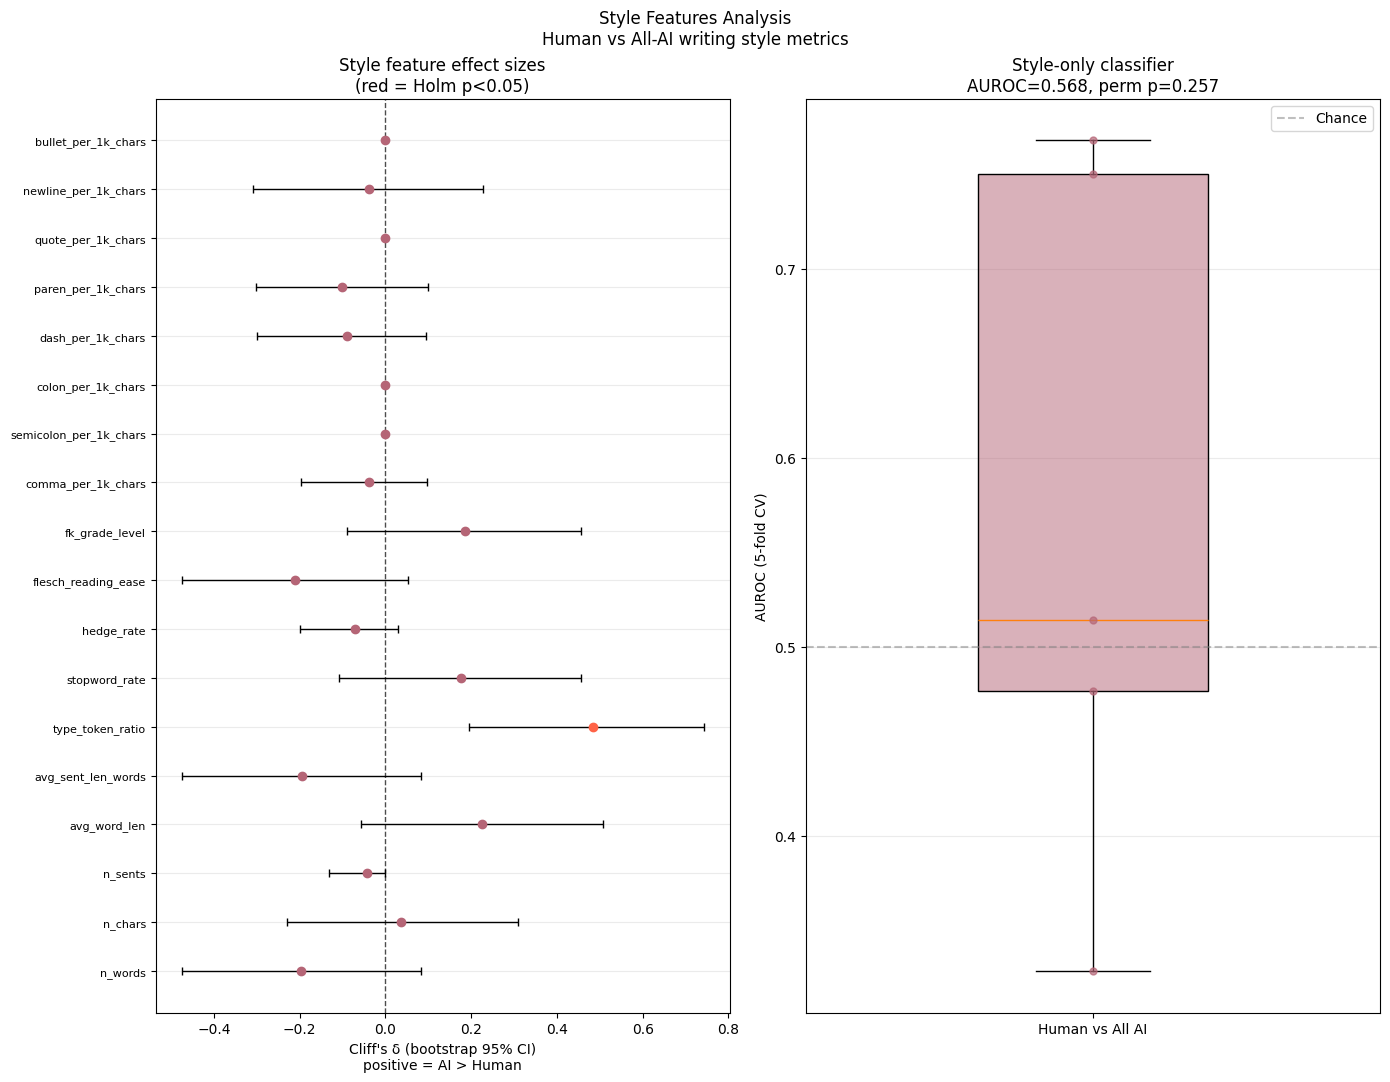

Saved style_human_vs_allai.png


In [83]:
if style_df is None:
    print('WARNING: style_df not loaded — skipping Part IV')
else:
    style_features_list = [
        'n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words',
        'type_token_ratio', 'stopword_rate', 'hedge_rate',
        'flesch_reading_ease', 'fk_grade_level',
        'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars',
        'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars',
        'newline_per_1k_chars', 'bullet_per_1k_chars'
    ]
    style_features_avail = [c for c in style_features_list if c in style_df.columns]

    # Determine group column
    style_group_col = 'group' if 'group' in style_df.columns else 'group_binary'
    if style_group_col not in style_df.columns:
        # Try merging with proposal_meta
        style_df = style_df.merge(proposal_meta[['title', 'group_binary']], on='title', how='left')
        style_group_col = 'group_binary'

    style_human = style_df[style_df[style_group_col] == 'Human']
    style_ai    = style_df[(style_df[style_group_col] == 'AI') |
                            (style_df[style_group_col].isin(['Claude', 'Gemini', 'GPT-5.2']))]
    if len(style_ai) == 0:
        # fallback
        is_ai_col = 'is_ai' if 'is_ai' in style_df.columns else None
        if is_ai_col:
            style_ai = style_df[style_df[is_ai_col] == 1]

    style_rows = []
    for col in style_features_avail:
        h_v = style_human[col].dropna().values
        a_v = style_ai[col].dropna().values
        if len(h_v) < 3 or len(a_v) < 3:
            continue
        stat_s, p_s = mannwhitneyu(a_v, h_v, alternative='two-sided')
        d_s = cliffs_delta(a_v, h_v)
        d_lo_s, d_hi_s = bootstrap_cliffs_delta_ci(a_v, h_v)
        style_rows.append({
            'feature': col,
            'human_mean': float(np.mean(h_v)), 'ai_mean': float(np.mean(a_v)),
            'mw_p': p_s, 'cliffs_delta': d_s,
            'cliffs_delta_ci_lo': d_lo_s, 'cliffs_delta_ci_hi': d_hi_s
        })
    style_out_df = pd.DataFrame(style_rows)
    if len(style_out_df) > 0:
        _, style_out_df['p_holm'], _, _ = multipletests(style_out_df['mw_p'], method='holm')
    style_out_df['mw_sig'] = style_out_df['mw_p'].apply(fmt_p)
    style_out_df.to_csv(TABLES_DIR_AI / 'style_features_human_vs_allai.csv', index=False)
    print(f'{(style_out_df["p_holm"] < 0.05).sum()} of {len(style_out_df)} '
          f'style features significant after Holm correction')
    print(style_out_df[['feature', 'human_mean', 'ai_mean', 'mw_p', 'p_holm', 'cliffs_delta']].to_string())

    # Style classifier (Human vs All-AI)
    if len(style_features_avail) > 0:
        from sklearn.preprocessing import StandardScaler
        style_all = pd.concat([style_human, style_ai], ignore_index=True)
        y_cls = np.array([1 if r[style_group_col] == 'Human' else 0
                          for _, r in style_all.iterrows()])
        X_cls = style_all[style_features_avail].fillna(0).values
        scaler = StandardScaler()
        X_cls_s = scaler.fit_transform(X_cls)

        clf = LogisticRegression(class_weight='balanced', max_iter=1000)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auroc_scores = cross_val_score(clf, X_cls_s, y_cls, cv=cv, scoring='roc_auc')
        mean_auroc = float(np.mean(auroc_scores))

        # Permutation test for AUROC
        rng_cls = np.random.default_rng(42)
        perm_aurocs = []
        for _ in range(500):
            y_perm = rng_cls.permutation(y_cls)
            perm_aurocs.append(float(np.mean(
                cross_val_score(clf, X_cls_s, y_perm, cv=cv, scoring='roc_auc'))))
        p_perm_cls = (np.sum(np.array(perm_aurocs) >= mean_auroc) + 1) / 501

        print(f'\nStyle classifier AUROC: {mean_auroc:.3f} (5-fold CV), perm p={p_perm_cls:.4f}')
        pd.DataFrame([{
            'cv_auroc_mean': mean_auroc, 'cv_auroc_std': float(np.std(auroc_scores)),
            'perm_p': p_perm_cls, 'n_features': len(style_features_avail)
        }]).to_csv(TABLES_DIR_AI / 'style_only_classifier_human_vs_allai.csv', index=False)

        # Figure: forest plot + AUROC box
        fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(style_features_avail) * 0.5 + 2)))
        fig.suptitle('Style Features Analysis\nHuman vs All-AI writing style metrics', fontsize=12)

        # Forest plot
        ax_f2 = axes[0]
        ax_f2.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
        ys2 = list(range(len(style_out_df)))
        for yi2, row_s in style_out_df.iterrows():
            col_s = 'tomato' if row_s.get('p_holm', 1) < 0.05 else AI_COLOR
            ax_f2.errorbar(row_s['cliffs_delta'], yi2,
                           xerr=[[row_s['cliffs_delta'] - row_s['cliffs_delta_ci_lo']],
                                 [row_s['cliffs_delta_ci_hi'] - row_s['cliffs_delta']]],
                           fmt='o', color=col_s, markersize=6,
                           ecolor='black', elinewidth=1.0, capsize=3)
        ax_f2.set_yticks(ys2)
        ax_f2.set_yticklabels(style_out_df['feature'].values, fontsize=8)
        ax_f2.set_xlabel("Cliff's δ (bootstrap 95% CI)\npositive = AI > Human")
        ax_f2.set_title('Style feature effect sizes\n(red = Holm p<0.05)')
        ax_f2.yaxis.grid(True, alpha=0.25)

        # AUROC
        ax_r = axes[1]
        ax_r.boxplot([auroc_scores], positions=[0], widths=0.4,
                     patch_artist=True,
                     boxprops=dict(facecolor=mcolors.to_rgba(AI_COLOR, 0.5)))
        ax_r.scatter(np.zeros(len(auroc_scores)), auroc_scores,
                     s=25, color=AI_COLOR, alpha=0.7, zorder=5)
        ax_r.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
        ax_r.set_xticks([0])
        ax_r.set_xticklabels(['Human vs All AI'])
        ax_r.set_ylabel('AUROC (5-fold CV)')
        ax_r.set_title(f'Style-only classifier\nAUROC={mean_auroc:.3f}, perm {fmt_p(p_perm_cls)}')
        ax_r.legend()
        ax_r.yaxis.grid(True, alpha=0.25)

        plt.tight_layout()
        fig.savefig(FIGURES_DIR_AI / 'style_human_vs_allai.png',
                    dpi=200, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print('Saved style_human_vs_allai.png')


## Finalize AI Heterogeneity Supplementary Table

In [84]:
_hetero_out = TABLES_DIR_AI / 'supplementary_ai_heterogeneity_kruskal_wallis.csv'
if _hetero_out.exists():
    hetero_final = pd.read_csv(_hetero_out)
    valid_h = hetero_final['p_kw'].notna()
    if valid_h.sum() > 0:
        rej_f, p_holm_f, _, _ = multipletests(
            hetero_final.loc[valid_h, 'p_kw'].values, alpha=0.05, method='holm')
        hetero_final.loc[valid_h, 'p_holm_final'] = p_holm_f
        hetero_final.loc[valid_h, 'sig_holm_final'] = rej_f
    hetero_final.to_csv(_hetero_out, index=False)
    n_sig_f = int(hetero_final.get('sig_holm_final', pd.Series(False)).sum())
    print(f'Heterogeneity summary: {n_sig_f} of {len(hetero_final)} outcomes '
          f'significantly heterogeneous across AI models (Holm correction).')
    print(hetero_final.to_string())
else:
    print('WARNING: heterogeneity table not found')


Heterogeneity summary: 8 of 14 outcomes significantly heterogeneous across AI models (Holm correction).
                               metric          H          p_kw  n_models        p_holm  rejected_holm  p_holm_final sig_holm_final
0     per_proposal_mean_pairwise_dist   3.901917  1.421377e-01         3  3.366091e-01          False  3.366091e-01          False
1         per_proposal_nn_dist_global   7.219976  2.705217e-02         3  1.623130e-01          False  1.623130e-01          False
2   per_proposal_global_centroid_dist   3.901917  1.421377e-01         3  3.366091e-01          False  3.366091e-01          False
3             novelty_element_novel_0  10.524872  5.182665e-03         3  3.627866e-02           True  3.627866e-02           True
4             novelty_element_novel_1  35.823711  1.663336e-08         3  2.328671e-07           True  2.328671e-07           True
5             novelty_element_novel_5  32.590440  8.376755e-08         3  1.088978e-06           True  1.08897

## Unified Summary Export

In [85]:
# Compile all primary results
summary_rows = []

# Diversity
summary_rows += [
    {'domain': 'Diversity', 'metric': 'Mean Pairwise Distance',
     'human_val': human_mpd, 'ai_boot_mean': ai_boot_mpd,
     'perm_p': p_perm_pp, 'cliffs_delta': delta, 'sig': fmt_p(p_perm_pp)},
    {'domain': 'Diversity', 'metric': 'LOO Centroid Distance',
     'human_val': human_loo_mean, 'ai_boot_mean': ai_boot_loo_mean,
     'perm_p': p_perm_loo, 'cliffs_delta': delta_loo, 'sig': fmt_p(p_perm_loo)},
    {'domain': 'Diversity', 'metric': 'Global Centroid Distance',
     'human_val': float(np.mean(human_gc)), 'ai_boot_mean': ai_boot_gc_mean,
     'perm_p': p_perm_gc, 'cliffs_delta': delta_gc, 'sig': fmt_p(p_perm_gc)},
    {'domain': 'Diversity', 'metric': 'MST Mean Edge Weight',
     'human_val': human_mst, 'ai_boot_mean': ai_boot_mst_mean,
     'perm_p': p_perm_mst, 'cliffs_delta': np.nan, 'sig': fmt_p(p_perm_mst)},
    {'domain': 'Diversity', 'metric': 'Sparseness (Medoid)',
     'human_val': human_spar, 'ai_boot_mean': ai_boot_spar_mean,
     'perm_p': p_perm_spar, 'cliffs_delta': delta_spar, 'sig': fmt_p(p_perm_spar)},
    {'domain': 'Diversity', 'metric': 'Chamfer (NN Distance)',
     'human_val': human_chamfer, 'ai_boot_mean': ai_boot_cham_mean,
     'perm_p': p_perm_nn, 'cliffs_delta': delta_nn, 'sig': fmt_p(p_perm_nn)},
    {'domain': 'Diversity', 'metric': 'Grid Entropy',
     'human_val': human_ent, 'ai_boot_mean': ai_boot_ent_mean,
     'perm_p': p_perm_ent, 'cliffs_delta': np.nan, 'sig': fmt_p(p_perm_ent)},
]

# Novelty (per-proposal MW p-values)
for _csv_name, _domain in [
    ('novelty_element_percentiles_human_vs_allai.csv', 'Novelty-Element'),
    ('novelty_knn_density_human_vs_allai.csv', 'Novelty-KNN'),
    ('bertopic_region_coverage_human_vs_allai.csv', 'BERTopic'),
    ('mesh_coverage_human_vs_allai.csv', 'MeSH'),
    ('style_features_human_vs_allai.csv', 'Style'),
]:
    _p = TABLES_DIR_AI / _csv_name
    if _p.exists():
        _tmp = pd.read_csv(_p)
        metric_col = 'metric' if 'metric' in _tmp.columns else \
                     ('feature' if 'feature' in _tmp.columns else _tmp.columns[0])
        for _, _r in _tmp.iterrows():
            summary_rows.append({
                'domain': _domain,
                'metric': _r.get(metric_col, ''),
                'human_val': _r.get('human_mean', np.nan),
                'ai_boot_mean': _r.get('ai_mean', np.nan),
                'perm_p': _r.get('mw_p', np.nan),
                'cliffs_delta': _r.get('cliffs_delta', np.nan),
                'sig': fmt_p(_r.get('mw_p', np.nan)) if not np.isnan(_r.get('mw_p', np.nan)) else 'n/a'
            })

summary_final = pd.DataFrame(summary_rows)
summary_final.to_csv(TABLES_DIR_AI / 'proposal_metrics_summary_human_vs_allai.csv', index=False)
print(f'Summary table: {len(summary_final)} rows across {summary_final["domain"].nunique()} domains')
print(summary_final.groupby('domain')['sig'].apply(lambda x: (x.isin(['***','**','*'])).sum()).reset_index(
    ).rename(columns={'sig': 'n_significant'}).to_string())
print('\nAll outputs saved to:', TABLES_DIR_AI)
print('All figures saved to:', FIGURES_DIR_AI)
print('\nNotebook complete.')


Summary table: 39 rows across 6 domains
            domain  n_significant
0         BERTopic              3
1        Diversity              6
2             MeSH              1
3  Novelty-Element              4
4      Novelty-KNN              5
5            Style              1

All outputs saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/all_ai
All figures saved to: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/all_ai

Notebook complete.
